# GKG 기반 GPR 대체 지수 산출
## 지정학적 위기 시 비트코인은 디지털 금인가? — 캡스톤디자인

---

### 작업 흐름

```
Step 0.  라이브러리 설치
Step 1.  전역 설정
Step 2. 전쟁 별 분할 처리(Step 2 ~ 5)
    Step 2 - 1.  CSV 로드 + 데이터 이해
    Step 2 - 2.  데이터 전처리
    Step 2 - 3.  GPR 대체 지수 5종 산출
            - F1: 단순 일평균 tone 역전 지수
            - F2: 극성 가중 tone 지수
            - F3: 보도량×tone 복합 지수
            - F4: 부정 비율 기반 지수
            - F5: 28일 지수가중 이동평균 지수
Step 3.  공식 GPR 로드
Step 4.  공식 GPR과 상관관계 분석
Step 5.  시각화
    Step 5-1. 이벤트별 F1~F5 시계열
    Step 5-2. 공식 GPR vs 우리 지수 직접 비교
    Step 5-3. 이벤트 전후 ±26일 GPR 변화 (이벤트 스터디형)
Step 6  결과 저장
```

### 입력 파일

| 파일명 | 이벤트 | 기준일 |
|---|---|---|
| `hormuz_crisis_raw_*.csv` | 호르무즈 해협 위기 | 2019-06-13 |
| `soleimani_assassination_raw_*.csv` | 솔레이마니 암살 | 2020-01-03 |
| `russia_ukraine_raw_*.csv` | 러-우 전쟁 | 2022-02-24 |
| `israel_hamas_raw_*.csv` | 이스라엘-하마스 전쟁 | 2023-10-07 |
| `israel_iran_raw_*.csv` | 이스라엘-이란 충돌 | 2024-04-01 |
| `us_israel_iran_raw_*.csv` | 이란 전쟁 | 2026-02-28 |



---
## Step 0. 라이브러리 설치

In [60]:
# !pip install pandas numpy matplotlib scipy openpyxl statsmodels --quiet

---
## Step 1. 전역 설정

In [2]:
import pandas as pd
import gcsfs
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as ticker
from scipy import stats
import warnings, os

warnings.filterwarnings('ignore')

import matplotlib, platform
if platform.system() == 'Windows':
    matplotlib.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin':
    matplotlib.rc('font', family='AppleGothic')
else:
    matplotlib.rc('font', family='DejaVu Sans')
matplotlib.rc('axes', unicode_minus=False)

print('라이브러리 로드 완료')
print(f'pandas {pd.__version__} / numpy {np.__version__}')

라이브러리 로드 완료
pandas 2.3.3 / numpy 2.2.6


In [3]:
EVENT_DATES = {
    'hormuz_crisis'          : '2019-06-13',
    'soleimani_assassination': '2020-01-03',
    'russia_ukraine_war': '2022-02-24',
    'israel_hamas_war'           : '2023-10-07',
    'israel_iran'            : '2024-04-01',
    'us_israel_iran'         : '2026-02-28',
}

EVENT_LABELS = {
    'hormuz_crisis'          : 'hormuz_crisis',
    'soleimani_assassination': 'soleimani_assassination',
    'russia_ukraine_war': 'russia_ukraine_war',
    'israel_hamas_war'         : 'israel_hamas_war',
    'israel_iran'            : 'israel_iran',
    'us_israel_iran'         : 'us_israel_iran',
}

EVENT_NAME_MAP = {
    'hormuz_crisis_raw': 'hormuz_crisis',
    'soleimani_assassination_raw': 'soleimani_assassination',
    'russia_ukraine_raw': 'russia_ukraine_war',
    'israel_hamas_raw': 'israel_hamas_war',
    'israel_iran_raw': 'israel_iran',
    'us_israel_iran_raw': 'us_israel_iran'
}

GPR_FILE = 'data_gpr_export.csv' 

COLORS = {
    'hormuz_crisis'          : '#E76F51',
    'soleimani_assassination': '#2A9D8F',
    'russia_ukraine_war': '#457B9D',
    'israel_hamas_war'           : '#8338EC',
    'israel_iran'            : '#E9C46A',
    'us_israel_iran'         : '#F4A261',
}


GEO_THEMES = [
    'ARMEDCONFLICT', 'CRISISLEX_T03_ARMED-CONFLICT',
    'WB_635_PEACE_AND_SECURITY', 'WB_2432_FRAGILITY_CONFLICT_AND_VIOLENCE',
    'WB_2470_PEACE_OPERATIONS_AND_CONFLICT_MANAGEMENT',
    'WB_2490_NATIONAL_PROTECTION_AND_SECURITY',
    'EPU_CATS_NATIONAL_SECURITY',
    'SANCTIONS', 'MILITARY', 'TAX_FNCACT_MILITARY',
    'MARITIME_INCIDENT', 'TERROR', 'KILL',
    'CRISISLEX_CRISISLEXREC', 'CRISISLEX_C07_SAFETY',
    'DRONES', 'CYBER_ATTACK',
]

print('전역 설정 완료')
print(f'GPR 파일 경로: {GPR_FILE}')

전역 설정 완료
GPR 파일 경로: data_gpr_export.csv


---
## Step 2. 전쟁 별 분할 처리 진행

---
### (1) hormuz_crisis, soleimani_assassination



#### Step 2 - 1. CSV 로드 + 데이터 이해

In [3]:
fs = gcsfs.GCSFileSystem()

cols_to_use = [
    'event_timestamp', 'event_date', 'url', 'tone_score', 
    'positive_score', 'negative_score', 'polarity', 'themes'
]

all_war_data = {}
war_list = ['hormuz_crisis_raw', 'soleimani_assassination_raw']

for war in war_list:
    path = f'gs://{war}/{war}_*'  
    files = fs.glob(path)
    
    if files:
        try:
            temp_df = pd.concat(
                [pd.read_csv(f"gs://{f}", usecols=cols_to_use) for f in files], 
                ignore_index=True
            )
            if 'event_date' in temp_df.columns:
                temp_df.rename(columns={'event_date': 'date'}, inplace=True)
            temp_df['event_label'] = war
            
            all_war_data[war] = temp_df
            print(f"✅ {war} 로드 완료: {len(temp_df)} 행")
        except Exception as e:
            print(f"❌ {war} 로드 중 오류 발생: {e}")

if all_war_data:
    total_war_df = pd.concat(all_war_data.values(), ignore_index=True)
    total_war_df = total_war_df.sort_values(by='event_timestamp', ascending=True).reset_index(drop=True)
    print(f"\n통합 완료! 전체 행 개수: {len(total_war_df)}")
    display(total_war_df.head())
else:
    print("로드된 데이터가 없습니다.")

✅ hormuz_crisis_raw 로드 완료: 322021 행
✅ soleimani_assassination_raw 로드 완료: 30385 행

통합 완료! 전체 행 개수: 352406


,event_timestamp,date,url,tone_score,positive_score,negative_score,polarity,themes,event_label
0,2019-01-01 00:00:00 UTC,2019-01-01,https://www.theburningplatform.com/2018/12/31/...,-8.836256,2.527898,11.364154,13.892052,"EPU_CATS_MONETARY_POLICY,9632;EPU_CATS_MONETAR...",hormuz_crisis_raw
1,2019-01-01 00:00:00 UTC,2019-01-01,https://www.theage.com.au/world/europe/echoes-...,-4.384724,1.414427,5.799151,7.213579,"TAX_FNCACT_DEPUTY,197;TAX_FNCACT_DEPUTY,2658;T...",hormuz_crisis_raw
2,2019-01-01 00:00:00 UTC,2019-01-01,https://hamodia.com/2018/12/31/iran-decks-elit...,1.775148,3.550296,1.775148,5.325444,"TAX_MILITARY_TITLE_ADMIRAL,361;TAX_FNCACT_ADMI...",hormuz_crisis_raw
3,2019-01-01 00:15:00 UTC,2019-01-01,http://www.lassennews.com/why-are-we-allowing-...,-6.213592,2.912621,9.126214,12.038835,"TERROR,3551;WB_2451_REBELS_GUERRILLAS_AND_INSU...",hormuz_crisis_raw
4,2019-01-01 00:15:00 UTC,2019-01-01,https://www.thedailytimes.com/news/nation_worl...,-1.522843,2.741117,4.263959,7.005076,"BAN,1141;TAX_FNCACT_DEPUTY,458;EPU_POLICY_CONG...",hormuz_crisis_raw


In [4]:
if 'total_war_df' in locals() and not total_war_df.empty:
    print(f'▶ 통합 데이터 탐색 진행\n')
    
    print('기간:', total_war_df["date"].min(), '~', total_war_df["date"].max())
    print('전체 행수:', len(total_war_df))
    print()
    
    print('결측치 합계:')
    print(total_war_df.isnull().sum())
    
    print('\n수치형 컬럼 기술통계:')
    
    stats_cols = ['tone_score', 'positive_score', 'negative_score', 'polarity']
    display(total_war_df[stats_cols].describe().round(3))
else:
    print('탐색할 데이터프레임(total_war_df)이 존재하지 않습니다.')

▶ 통합 데이터 탐색 진행

기간: 2019-01-01 ~ 2021-01-28
전체 행수: 352406

결측치 합계:
event_timestamp    0
date               0
url                0
tone_score         0
positive_score     0
negative_score     0
polarity           0
themes             0
event_label        0
dtype: int64

수치형 컬럼 기술통계:


,tone_score,positive_score,negative_score,polarity
count,352406.000,352406.000,352406.000,352406.000
mean,-3.781,1.947,5.729,7.676
std,2.304,0.965,1.969,2.074
min,-21.875,0.000,0.000,0.000
25%,-5.182,1.292,4.406,6.271
50%,-3.733,1.840,5.620,7.570
75%,-2.322,2.481,6.907,8.935
max,13.260,14.917,21.875,25.000


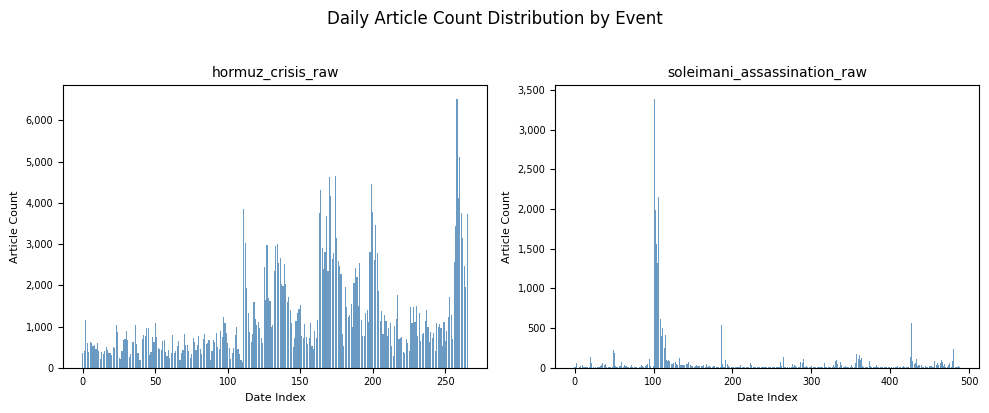

Saved: 01-1_hormuz_soleimani_article_count.png


In [14]:
if all_war_data:
    n_raw=len(all_war_data)
    fig,axes=plt.subplots(1,n_raw,figsize=(5*n_raw,4))
    if n_raw==1: axes=[axes]

    for ax,(event,df) in zip(axes,all_war_data.items()):
        daily_cnt=df.groupby('date').size().sort_index()
        dates_list=daily_cnt.index.tolist()

        ax.bar(range(len(daily_cnt)),daily_cnt.values,color=COLORS.get(event,'steelblue'),alpha=0.8)

        event_origin_date=EVENT_DATES.get(event)

        if event_origin_date in dates_list:
            event_idx=dates_list.index(event_origin_date)

            ax.axvline(x=event_idx,color='red',linestyle='--',linewidth=1.5,label='Event Date')

            ax.text(event_idx,ax.get_ylim()[1]*0.9,'Event Date',color='red',fontsize=8,ha='center',va='bottom')

        ax.set_title(EVENT_LABELS.get(event,event),fontsize=10)
        ax.set_xlabel('Date Index',fontsize=8)
        ax.set_ylabel('Article Count',fontsize=8)
        ax.tick_params(axis='both',labelsize=7)

        ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x,_: f'{int(x):,}'))

    plt.suptitle('Daily Article Count Distribution by Event',fontsize=12,y=1.02)
    plt.tight_layout()
    plt.savefig('01-1_hormuz_soleimani_article_count.png',dpi=150,bbox_inches='tight')
    plt.show()

    print('Saved: 01-1_hormuz_soleimani_article_count.png')

else:
    print('No available data in all_war_data')

---
#### Step 2 - 2.  데이터 전처리

In [6]:
MIN_DAILY_COUNT    = 5
TONE_OUTLIER_BOUND = 20

def has_geo_theme(themes_str):
    if pd.isna(themes_str) or themes_str == '':
        return False
    return any(tag in themes_str for tag in GEO_THEMES)

def preprocess(df, event_name):
    log = {'event': event_name, 'raw': len(df)}
    df  = df.copy()

    df = df.drop_duplicates(subset=['url'])
    log['after_dedup'] = len(df)

    df = df.dropna(subset=['tone_score','positive_score',
                            'negative_score','polarity'])
    log['after_tone_na'] = len(df)

    df = df[df['tone_score'].abs() <= TONE_OUTLIER_BOUND]
    log['after_outlier'] = len(df)

    for col in ['themes']:
        df[col] = df[col].fillna('')

    df['event_timestamp'] = pd.to_datetime(df['event_timestamp'])
    df['_date'] = df['event_timestamp'].dt.tz_convert(None).dt.normalize()

    df = df[df['themes'].apply(has_geo_theme)]
    log['after_geo_filter'] = len(df)

    daily_cnt   = df.groupby('_date').size()
    valid_dates = daily_cnt[daily_cnt >= MIN_DAILY_COUNT].index
    df = df[df['_date'].isin(valid_dates)]
    log['after_min_count'] = len(df)
    log['valid_days']      = df['_date'].nunique()

    return df, log

clean_dfs = {}
logs = []
print('▶ 데이터 전처리\n')
header = (f'{"이벤트":<30} {"raw":>8} {"중복제거":>8} '
          f'{"이상값":>8} {"지정학":>8} {"최소건수":>8} {"유효일":>6}')
print(header)
print('-' * len(header))
for label, group_df in total_war_df.groupby('event_label'):
    cleaned, log = preprocess(group_df, label)
    
    clean_dfs[label] = cleaned
    logs.append(log)
    
    print(f"{label:<30} "
          f"{log['raw']:>8,} {log['after_dedup']:>8,} "
          f"{log['after_outlier']:>8,} {log['after_geo_filter']:>8,} "
          f"{log['after_min_count']:>8,} {log['valid_days']:>6}")

preprocess_log_df = pd.DataFrame(logs)
print(f'\n✨ 전처리 완료: {len(clean_dfs)}개 이벤트')

▶ 데이터 전처리

이벤트                                 raw     중복제거      이상값      지정학     최소건수    유효일
----------------------------------------------------------------------------------
hormuz_crisis_raw               322,021  322,021  322,018  322,018  322,018    266
soleimani_assassination_raw      30,385   30,385   30,382   30,382   30,224    438

✨ 전처리 완료: 2개 이벤트


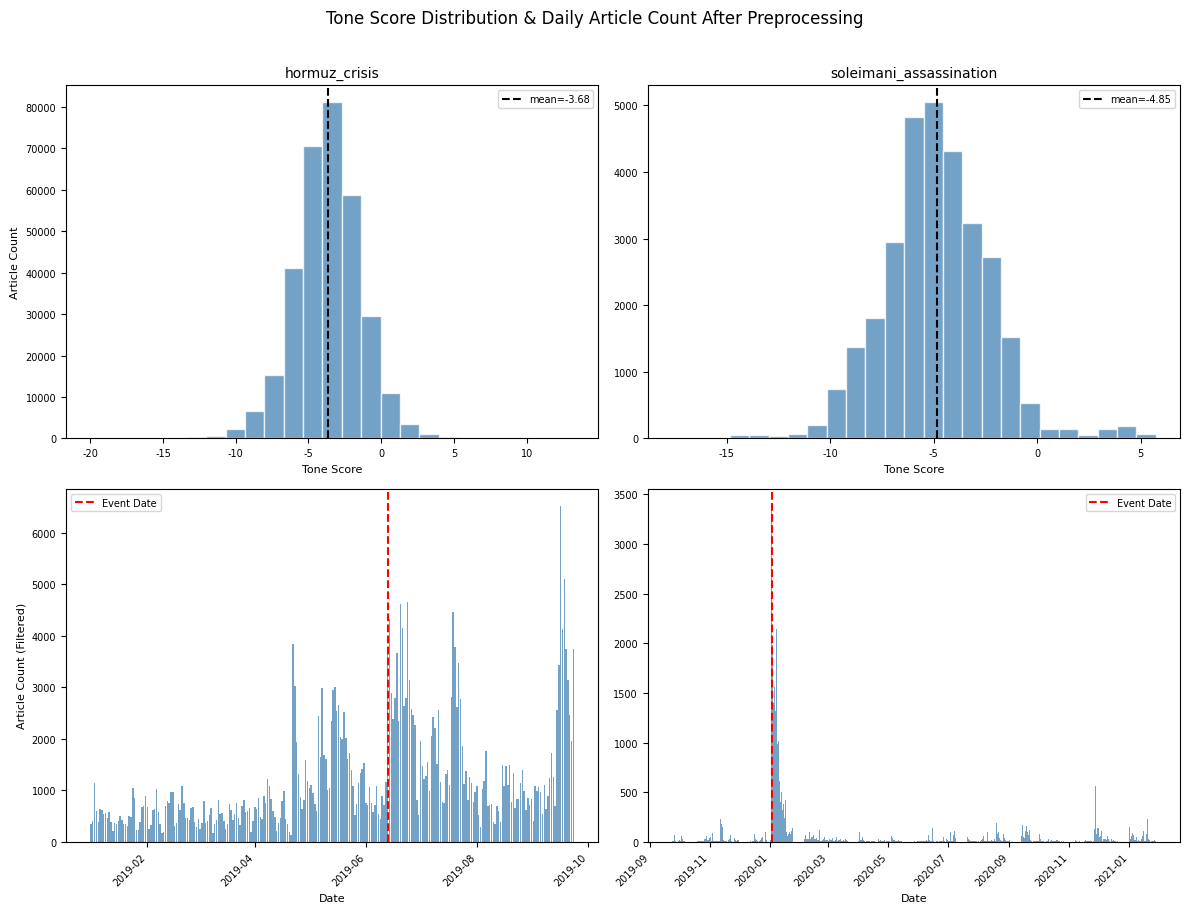

Saved: 02-1_hormuz_soleimani_preprocessed.png


In [15]:
if clean_dfs:
    n_ev=len(clean_dfs)
    fig,axes=plt.subplots(2,n_ev,figsize=(6*n_ev,9),squeeze=False)

    for col_i,(event,df) in enumerate(clean_dfs.items()):
        color=COLORS.get(event,'steelblue')

        ax0=axes[0,col_i]
        ax0.hist(df['tone_score'],bins=25,color=color,alpha=0.75,edgecolor='white')
        ax0.axvline(df['tone_score'].mean(),color='black',lw=1.5,ls='--',label=f"mean={df['tone_score'].mean():.2f}")
        ax0.set_title(EVENT_LABELS.get(EVENT_NAME_MAP[event],event),fontsize=10)
        ax0.set_xlabel('Tone Score',fontsize=8)
        ax0.legend(fontsize=7)
        ax0.tick_params(axis='both',labelsize=7)
        if col_i==0:
            ax0.set_ylabel('Article Count',fontsize=8)
        ax1=axes[1,col_i]
        daily_cnt=df.groupby('_date').size()
        clean_event=EVENT_NAME_MAP[event]
        event_dt=pd.Timestamp(EVENT_DATES[clean_event])
        ax1.bar(daily_cnt.index,daily_cnt.values,color=color,alpha=0.75)
        ax1.axvline(event_dt,color='red',lw=1.5,ls='--',label='Event Date')
        ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
        ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
        plt.setp(ax1.xaxis.get_majorticklabels(),rotation=45,ha='right')
        ax1.set_xlabel('Date',fontsize=8)
        ax1.legend(fontsize=7)
        ax1.tick_params(axis='both',labelsize=7)
        if col_i==0:
            ax1.set_ylabel('Article Count (Filtered)',fontsize=8)

    plt.suptitle('Tone Score Distribution & Daily Article Count After Preprocessing',fontsize=12,y=1.01)
    plt.tight_layout()
    plt.savefig('02-1_hormuz_soleimani_preprocessed.png',dpi=150,bbox_inches='tight')
    plt.show()

    print('Saved: 02-1_hormuz_soleimani_preprocessed.png')

---
#### Step 2 - 3.  GPR 대체 지수 5종 산출

In [9]:
def compute_gpr_indices(df, event_name):
    df = df.dropna(subset=['tone_score','positive_score',
                            'negative_score','polarity']).copy()

    df['tone_x_polarity'] = df['tone_score'] * df['polarity']

    agg = df.groupby('_date').agg(
        N                   = ('tone_score',      'count'),
        mean_tone           = ('tone_score',      'mean'),
        sum_tone_x_polarity = ('tone_x_polarity', 'sum'),
        sum_polarity        = ('polarity',         'sum'),
        mean_pos            = ('positive_score',  'mean'),
        mean_neg            = ('negative_score',  'mean'),
    ).copy()
    
    avg_n = agg['N'].mean()

    agg['relative_N'] = agg['N'] / avg_n
    agg['coverage_scaled'] = np.log1p(agg['relative_N'])

    agg['F1_raw'] = -agg['mean_tone']

    agg['F2_raw'] = np.where(
        agg['sum_polarity'] > 0,
        -agg['sum_tone_x_polarity'] / agg['sum_polarity'],
        np.nan)

    agg['F3_raw'] = -agg['mean_tone'] * agg['coverage_scaled']

    denom = agg['mean_pos'] + agg['mean_neg']
    agg['F4_raw'] = np.where(denom > 1e-6, agg['mean_neg'] / denom, np.nan)

    r, WND = 0.1, 28
    raw_w   = np.array([(1 - r) ** k for k in range(WND)])
    weights = raw_w / raw_w.sum()

    def ewma_28(series):
        result = np.full(len(series), np.nan)
        arr    = series.values
        for i in range(len(arr)):
            window = arr[max(0, i - WND + 1): i + 1][::-1]
            w_cut  = weights[:len(window)]
            w_cut  = w_cut / w_cut.sum()
            valid  = ~np.isnan(window)
            if valid.sum() > 0:
                result[i] = (np.nansum(window[valid] * w_cut[valid])
                             / w_cut[valid].sum())
        return pd.Series(result, index=series.index)

    agg = agg.sort_index()
    agg['F5_raw'] = ewma_28(agg['F2_raw'])

    for f in ['F1','F2','F3','F4','F5']:
        col = f'{f}_raw'
        mu, sig = agg[col].mean(), agg[col].std()
        agg[f'{f}_z'] = (agg[col] - mu) / sig if sig > 0 else np.nan

    clean_event_name = EVENT_NAME_MAP[event_name]

    agg['event_name'] = clean_event_name
    agg['event_date'] = EVENT_DATES[clean_event_name]
    return agg.reset_index().rename(columns={'_date': 'date'})


gpr_results = {}
print('▶ GPR 대체 지수 5종 산출\n')
print(f'{"이벤트":<30} {"유효일":>6} {"F1 mean":>9} {"F2 mean":>9} {"F3 mean":>9}')
print('-' * 70)
for event, df in clean_dfs.items():
    result = compute_gpr_indices(df, event)
    gpr_results[event] = result
    print(f"{event:<30} {len(result):>6} "
          f"{result['F1_raw'].mean():>9.3f} "
          f"{result['F2_raw'].mean():>9.3f} "
          f"{result['F3_raw'].mean():>9.3f}")
gpr_all = pd.concat(gpr_results.values(), ignore_index=True)
print(f'\n산출 완료: 총 {len(gpr_all)}행')

▶ GPR 대체 지수 5종 산출

이벤트                               유효일   F1 mean   F2 mean   F3 mean
----------------------------------------------------------------------
hormuz_crisis_raw                 266     3.412     3.783     2.232
soleimani_assassination_raw       438     4.483     4.770     1.865

산출 완료: 총 704행


In [10]:
output_filename = 'gpr_hormuz_soleimani.csv.csv'

gpr_all.to_csv(output_filename, index=False, encoding='utf-8-sig')

print(f'✅ 저장 완료: {output_filename}')

✅ 저장 완료: gpr_hormuz_soleimani.csv.csv


### (2) russia_ukraine_war


#### Step 2 - 1. CSV 로드 + 데이터 이해

In [3]:
fs = gcsfs.GCSFileSystem()

cols_to_use = [
    'event_timestamp', 'event_date', 'url', 'tone_score', 
    'positive_score', 'negative_score', 'polarity', 'themes'
]

all_war_data = {}
war_list = ['russia_ukraine_raw']

for war in war_list:
    path = f'gs://{war}/{war}_*'  
    files = fs.glob(path)
    
    if files:
        try:
            temp_df = pd.concat(
                [pd.read_csv(f"gs://{f}", usecols=cols_to_use) for f in files], 
                ignore_index=True
            )
            if 'event_date' in temp_df.columns:
                temp_df.rename(columns={'event_date': 'date'}, inplace=True)
            temp_df['event_label'] = war
            
            all_war_data[war] = temp_df
            print(f"✅ {war} 로드 완료: {len(temp_df)} 행")
        except Exception as e:
            print(f"❌ {war} 로드 중 오류 발생: {e}")

if all_war_data:
    total_war_df = pd.concat(all_war_data.values(), ignore_index=True)
    total_war_df = total_war_df.sort_values(by='event_timestamp', ascending=True).reset_index(drop=True)
    print(f"\n🚀 최종 통합 완료! 전체 행 개수: {len(total_war_df)}")
    display(total_war_df.head())
else:
    print("로드된 데이터가 없습니다.")

✅ russia_ukraine_raw 로드 완료: 3226284 행

🚀 최종 통합 완료! 전체 행 개수: 3226284


,event_timestamp,date,url,tone_score,positive_score,negative_score,polarity,themes,event_label
0,2021-01-29 00:00:00 UTC,2021-01-29,https://www.metro.us/u-n-chief-to-foreign/,-3.896104,2.272727,6.168831,8.441558,"GENERAL_GOVERNMENT,313;GENERAL_GOVERNMENT,619;...",russia_ukraine_raw
1,2021-01-29 00:00:00 UTC,2021-01-29,https://www.jdsupra.com/legalnews/the-state-of...,-2.404121,2.461362,4.865484,7.326846,"CYBER_ATTACK,3337;CYBER_ATTACK,7228;WB_678_DIG...",russia_ukraine_raw
2,2021-01-29 00:00:00 UTC,2021-01-29,https://www.europesun.com/news/267670458/maryl...,-7.317073,0.813008,8.130081,8.943089,"GENERAL_GOVERNMENT,319;EPU_POLICY_GOVERNMENT,3...",russia_ukraine_raw
3,2021-01-29 00:00:00 UTC,2021-01-29,https://www.europesun.com/news/267676332/who-e...,-3.846154,1.923077,5.769231,7.692308,"SHORTAGE,1106;TAX_FNCACT_DIRECTOR,45;TAX_FNCAC...",russia_ukraine_raw
4,2021-01-29 00:00:00 UTC,2021-01-29,https://www.azerbaijannews.net/news/267676198/...,-7.322654,2.440885,9.763539,12.204424,"TAX_DISEASE_BLAST_INJURIES,2231;TAX_DISEASE_BL...",russia_ukraine_raw


In [9]:
if 'total_war_df' in locals() and not total_war_df.empty:
    print(f'▶ 통합 데이터 탐색 진행\n')
    
    print('기간:', total_war_df["date"].min(), '~', total_war_df["date"].max())
    print('전체 행수:', len(total_war_df))
    print()
    
    print('결측치 합계:')
    print(total_war_df.isnull().sum())
    
    print('\n수치형 컬럼 기술통계:')
    stats_cols = ['tone_score', 'positive_score', 'negative_score', 'polarity']
    display(total_war_df[stats_cols].describe().round(3))
else:
    print('탐색할 데이터프레임(total_war_df)이 존재하지 않습니다.')

▶ 통합 데이터 탐색 진행

기간: 2021-01-29 ~ 2022-12-15
전체 행수: 3226284

결측치 합계:
event_timestamp    0
date               0
url                0
tone_score         0
positive_score     0
negative_score     0
polarity           0
themes             0
event_label        0
dtype: int64

수치형 컬럼 기술통계:


,tone_score,positive_score,negative_score,polarity
count,3226284.000,3226284.000,3226284.000,3226284.000
mean,-2.916,2.232,5.148,7.380
std,2.859,1.275,2.296,2.371
min,-42.857,0.000,0.000,0.000
25%,-4.661,1.391,3.559,5.797
50%,-2.857,2.058,4.982,7.244
75%,-1.102,2.869,6.505,8.777
max,20.561,20.561,42.857,42.857


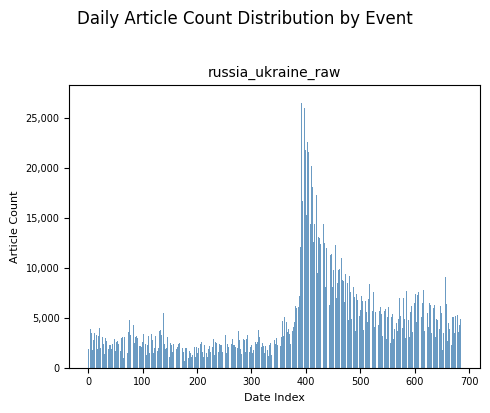

Saved: 01-2_russia_ukraine_article_count.png


In [8]:
if all_war_data:
    n_raw=len(all_war_data)
    fig,axes=plt.subplots(1,n_raw,figsize=(5*n_raw,4))
    if n_raw==1: axes=[axes]

    for ax,(event,df) in zip(axes,all_war_data.items()):
        daily_cnt=df.groupby('date').size().sort_index()
        dates_list=daily_cnt.index.tolist()

        ax.bar(range(len(daily_cnt)),daily_cnt.values,color=COLORS.get(event,'steelblue'),alpha=0.8)

        event_origin_date=EVENT_DATES.get(event)

        if event_origin_date in dates_list:
            event_idx=dates_list.index(event_origin_date)

            ax.axvline(x=event_idx,color='red',linestyle='--',linewidth=1.5,label='Event Date')

            ax.text(event_idx,ax.get_ylim()[1]*0.9,'Event Date',color='red',fontsize=8,ha='center',va='bottom')

        ax.set_title(EVENT_LABELS.get(event,event),fontsize=10)
        ax.set_xlabel('Date Index',fontsize=8)
        ax.set_ylabel('Article Count',fontsize=8)
        ax.tick_params(axis='both',labelsize=7)

        ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x,_: f'{int(x):,}'))

    plt.suptitle('Daily Article Count Distribution by Event',fontsize=12,y=1.02)
    plt.tight_layout()
    plt.savefig('01-2_russia_ukraine_article_count.png',dpi=150,bbox_inches='tight')
    plt.show()

    print('Saved: 01-2_russia_ukraine_article_count.png')

else:
    print('No available data in all_war_data')

---
#### Step 2 - 2.  데이터 전처리

In [10]:
MIN_DAILY_COUNT    = 5
TONE_OUTLIER_BOUND = 20

def has_geo_theme(themes_str):
    if pd.isna(themes_str) or themes_str == '':
        return False
    return any(tag in themes_str for tag in GEO_THEMES)

def preprocess(df, event_name):
    log = {'event': event_name, 'raw': len(df)}
    df  = df.copy()

    df = df.drop_duplicates(subset=['url'])
    log['after_dedup'] = len(df)

    df = df.dropna(subset=['tone_score','positive_score',
                            'negative_score','polarity'])
    log['after_tone_na'] = len(df)

    df = df[df['tone_score'].abs() <= TONE_OUTLIER_BOUND]
    log['after_outlier'] = len(df)

    for col in ['themes']:
        df[col] = df[col].fillna('')

    df['event_timestamp'] = pd.to_datetime(df['event_timestamp'])
    df['_date'] = df['event_timestamp'].dt.tz_convert(None).dt.normalize()

    df = df[df['themes'].apply(has_geo_theme)]
    log['after_geo_filter'] = len(df)

    daily_cnt   = df.groupby('_date').size()
    valid_dates = daily_cnt[daily_cnt >= MIN_DAILY_COUNT].index
    df = df[df['_date'].isin(valid_dates)]
    log['after_min_count'] = len(df)
    log['valid_days']      = df['_date'].nunique()

    return df, log

clean_dfs = {}
logs = []
print('▶ 데이터 전처리\n')
header = (f'{"이벤트":<30} {"raw":>8} {"중복제거":>8} '
          f'{"이상값":>8} {"지정학":>8} {"최소건수":>8} {"유효일":>6}')
print(header)
print('-' * len(header))
for label, group_df in total_war_df.groupby('event_label'):
    cleaned, log = preprocess(group_df, label)
    
    clean_dfs[label] = cleaned
    logs.append(log)

    print(f"{label:<30} "
          f"{log['raw']:>8,} {log['after_dedup']:>8,} "
          f"{log['after_outlier']:>8,} {log['after_geo_filter']:>8,} "
          f"{log['after_min_count']:>8,} {log['valid_days']:>6}")

preprocess_log_df = pd.DataFrame(logs)
print(f'\n✨ 전처리 완료: {len(clean_dfs)}개 이벤트')

▶ 데이터 전처리

이벤트                                 raw     중복제거      이상값      지정학     최소건수    유효일
----------------------------------------------------------------------------------
russia_ukraine_raw             3,226,284 3,226,284 3,225,754 3,225,754 3,225,754    686

✨ 전처리 완료: 1개 이벤트


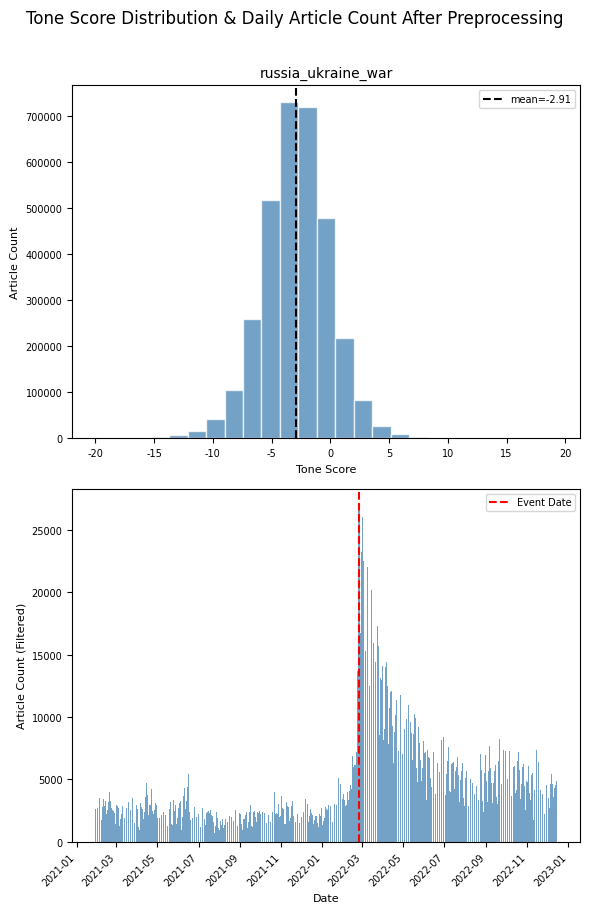

Saved: 02-2_russia_ukraine_preprocessed.png


In [14]:
if clean_dfs:
    n_ev=len(clean_dfs)
    fig,axes=plt.subplots(2,n_ev,figsize=(6*n_ev,9),squeeze=False)

    for col_i,(event,df) in enumerate(clean_dfs.items()):
        color=COLORS.get(event,'steelblue')

        ax0=axes[0,col_i]
        ax0.hist(df['tone_score'],bins=25,color=color,alpha=0.75,edgecolor='white')
        ax0.axvline(df['tone_score'].mean(),color='black',lw=1.5,ls='--',label=f"mean={df['tone_score'].mean():.2f}")
        ax0.set_title(EVENT_LABELS.get(EVENT_NAME_MAP[event],event),fontsize=10)
        ax0.set_xlabel('Tone Score',fontsize=8)
        ax0.legend(fontsize=7)
        ax0.tick_params(axis='both',labelsize=7)
        if col_i==0:
            ax0.set_ylabel('Article Count',fontsize=8)
        ax1=axes[1,col_i]
        daily_cnt=df.groupby('_date').size()
        clean_event=EVENT_NAME_MAP[event]
        event_dt=pd.Timestamp(EVENT_DATES[clean_event])
        ax1.bar(daily_cnt.index,daily_cnt.values,color=color,alpha=0.75)
        ax1.axvline(event_dt,color='red',lw=1.5,ls='--',label='Event Date')
        ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
        ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
        plt.setp(ax1.xaxis.get_majorticklabels(),rotation=45,ha='right')
        ax1.set_xlabel('Date',fontsize=8)
        ax1.legend(fontsize=7)
        ax1.tick_params(axis='both',labelsize=7)
        if col_i==0:
            ax1.set_ylabel('Article Count (Filtered)',fontsize=8)

    plt.suptitle('Tone Score Distribution & Daily Article Count After Preprocessing',fontsize=12,y=1.01)
    plt.tight_layout()
    plt.savefig('02-2_russia_ukraine_preprocessed.png',dpi=150,bbox_inches='tight')
    plt.show()

    print('Saved: 02-2_russia_ukraine_preprocessed.png')

---
#### Step 2 - 3.  GPR 대체 지수 5종 산출

In [12]:
def compute_gpr_indices(df, event_name):
    df = df.dropna(subset=['tone_score','positive_score',
                            'negative_score','polarity']).copy()

    df['tone_x_polarity'] = df['tone_score'] * df['polarity']

    agg = df.groupby('_date').agg(
        N                   = ('tone_score',      'count'),
        mean_tone           = ('tone_score',      'mean'),
        sum_tone_x_polarity = ('tone_x_polarity', 'sum'),
        sum_polarity        = ('polarity',         'sum'),
        mean_pos            = ('positive_score',  'mean'),
        mean_neg            = ('negative_score',  'mean'),
    ).copy()
    
    avg_n = agg['N'].mean()
    agg['relative_N'] = agg['N'] / avg_n
    agg['coverage_scaled'] = np.log1p(agg['relative_N'])

    agg['F1_raw'] = -agg['mean_tone']

    agg['F2_raw'] = np.where(
        agg['sum_polarity'] > 0,
        -agg['sum_tone_x_polarity'] / agg['sum_polarity'],
        np.nan)

    agg['F3_raw'] = -agg['mean_tone'] * agg['coverage_scaled']

    denom = agg['mean_pos'] + agg['mean_neg']
    agg['F4_raw'] = np.where(denom > 1e-6, agg['mean_neg'] / denom, np.nan)

    r, WND = 0.1, 28
    raw_w   = np.array([(1 - r) ** k for k in range(WND)])
    weights = raw_w / raw_w.sum()

    def ewma_28(series):
        result = np.full(len(series), np.nan)
        arr    = series.values
        for i in range(len(arr)):
            window = arr[max(0, i - WND + 1): i + 1][::-1]
            w_cut  = weights[:len(window)]
            w_cut  = w_cut / w_cut.sum()
            valid  = ~np.isnan(window)
            if valid.sum() > 0:
                result[i] = (np.nansum(window[valid] * w_cut[valid])
                             / w_cut[valid].sum())
        return pd.Series(result, index=series.index)

    agg = agg.sort_index()
    agg['F5_raw'] = ewma_28(agg['F2_raw'])

    for f in ['F1','F2','F3','F4','F5']:
        col = f'{f}_raw'
        mu, sig = agg[col].mean(), agg[col].std()
        agg[f'{f}_z'] = (agg[col] - mu) / sig if sig > 0 else np.nan

    clean_event_name = EVENT_NAME_MAP[event_name]

    agg['event_name'] = clean_event_name
    agg['event_date'] = EVENT_DATES[clean_event_name]
    return agg.reset_index().rename(columns={'_date': 'date'})


gpr_results = {}
print('▶ GPR 대체 지수 5종 산출\n')
print(f'{"이벤트":<30} {"유효일":>6} {"F1 mean":>9} {"F2 mean":>9} {"F3 mean":>9}')
print('-' * 70)
for event, df in clean_dfs.items():
    result = compute_gpr_indices(df, event)
    gpr_results[event] = result
    print(f"{event:<30} {len(result):>6} "
          f"{result['F1_raw'].mean():>9.3f} "
          f"{result['F2_raw'].mean():>9.3f} "
          f"{result['F3_raw'].mean():>9.3f}")
gpr_all = pd.concat(gpr_results.values(), ignore_index=True)
print(f'\n산출 완료: 총 {len(gpr_all)}행')

▶ GPR 대체 지수 5종 산출

이벤트                               유효일   F1 mean   F2 mean   F3 mean
----------------------------------------------------------------------
russia_ukraine_raw                686     2.864     3.364     1.811

산출 완료: 총 686행


In [13]:
output_filename = 'gpr_russia_ukraine.csv'

gpr_all.to_csv(output_filename, index=False, encoding='utf-8-sig')

print(f'✅ 저장 완료: {output_filename}')

✅ 저장 완료: gpr_russia_ukraine.csv


### (3) israel_hamas_war, israel_iran

#### Step 2 - 1. CSV 로드 + 데이터 이해

In [ ]:
fs = gcsfs.GCSFileSystem()

cols_to_use = [
    'event_timestamp', 'event_date', 'url', 'tone_score', 
    'positive_score', 'negative_score', 'polarity', 'themes'
]

all_war_data = {}
war_list = ['israel_hamas_raw', 'israel_iran_raw']


for war in war_list:
    path = f'gs://{war}/{war}_*'  
    files = fs.glob(path)
    
    if files:
        try:
            temp_df = pd.concat(
                [pd.read_csv(f"gs://{f}", usecols=cols_to_use) for f in files], 
                ignore_index=True
            )
            if 'event_date' in temp_df.columns:
                temp_df.rename(columns={'event_date': 'date'}, inplace=True)
            temp_df['event_label'] = war
            
            all_war_data[war] = temp_df
            print(f"✅ {war} 로드 완료: {len(temp_df)} 행")
        except Exception as e:
            print(f"❌ {war} 로드 중 오류 발생: {e}")

if all_war_data:
    total_war_df = pd.concat(all_war_data.values(), ignore_index=True)
    total_war_df = total_war_df.sort_values(by='event_timestamp', ascending=True).reset_index(drop=True)
    print(f"\n🚀 최종 통합 완료! 전체 행 개수: {len(total_war_df)}")
    display(total_war_df.head())
else:
    print("로드된 데이터가 없습니다.")

✅ israel_hamas_raw 로드 완료: 1280948 행


In [12]:
if 'total_war_df' in locals() and not total_war_df.empty:
    print(f'▶ 통합 데이터 탐색 진행\n')
    
    print('기간:', total_war_df["date"].min(), '~', total_war_df["date"].max())
    print('전체 행수:', len(total_war_df))
    print()
    
    print('결측치 합계:')
    print(total_war_df.isnull().sum())
    
    print('\n수치형 컬럼 기술통계:')
    stats_cols = ['tone_score', 'positive_score', 'negative_score', 'polarity']
    display(total_war_df[stats_cols].describe().round(3))
else:
    print('탐색할 데이터프레임(total_war_df)이 존재하지 않습니다.')

▶ 통합 데이터 탐색 진행

기간: 2022-12-16 ~ 2025-03-16
전체 행수: 3399667

결측치 합계:
event_timestamp    0
date               0
url                0
tone_score         0
positive_score     0
negative_score     0
polarity           0
themes             0
event_label        0
dtype: int64

수치형 컬럼 기술통계:


,tone_score,positive_score,negative_score,polarity
count,3399667.000,3399667.000,3399667.000,3399667.000
mean,-3.984,2.254,6.238,8.491
std,3.215,1.291,2.570,2.491
min,-44.444,0.000,0.000,0.000
25%,-6.087,1.397,4.442,6.829
50%,-4.011,2.083,6.164,8.425
75%,-1.880,2.914,7.882,10.000
max,23.077,23.077,44.444,46.667


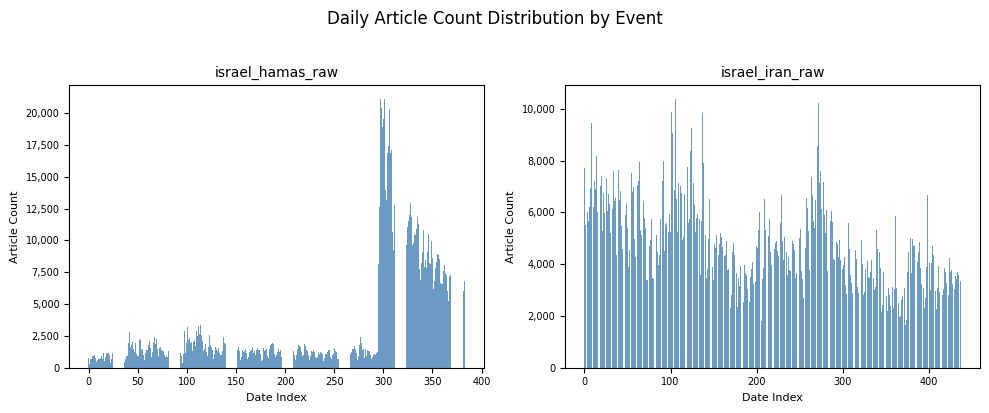

Saved: 01-3_israel_hamas_iran_article_count.png


In [13]:
if all_war_data:
    n_raw=len(all_war_data)
    fig,axes=plt.subplots(1,n_raw,figsize=(5*n_raw,4))
    if n_raw==1: axes=[axes]

    for ax,(event,df) in zip(axes,all_war_data.items()):
        daily_cnt=df.groupby('date').size().sort_index()
        dates_list=daily_cnt.index.tolist()

        ax.bar(range(len(daily_cnt)),daily_cnt.values,color=COLORS.get(event,'steelblue'),alpha=0.8)

        event_origin_date=EVENT_DATES.get(event)

        if event_origin_date in dates_list:
            event_idx=dates_list.index(event_origin_date)

            ax.axvline(x=event_idx,color='red',linestyle='--',linewidth=1.5,label='Event Date')

            ax.text(event_idx,ax.get_ylim()[1]*0.9,'Event Date',color='red',fontsize=8,ha='center',va='bottom')

        ax.set_title(EVENT_LABELS.get(event,event),fontsize=10)
        ax.set_xlabel('Date Index',fontsize=8)
        ax.set_ylabel('Article Count',fontsize=8)
        ax.tick_params(axis='both',labelsize=7)

        ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x,_: f'{int(x):,}'))

    plt.suptitle('Daily Article Count Distribution by Event',fontsize=12,y=1.02)
    plt.tight_layout()
    plt.savefig('01-3_israel_hamas_iran_article_count.png',dpi=150,bbox_inches='tight')
    plt.show()

    print('Saved: 01-3_israel_hamas_iran_article_count.png')

else:
    print('No available data in all_war_data')

#### Step 2 - 2. 데이터 전처리

In [14]:
MIN_DAILY_COUNT    = 5
TONE_OUTLIER_BOUND = 20

def has_geo_theme(themes_str):
    if pd.isna(themes_str) or themes_str == '':
        return False
    return any(tag in themes_str for tag in GEO_THEMES)

def preprocess(df, event_name):
    log = {'event': event_name, 'raw': len(df)}
    df  = df.copy()

    df = df.drop_duplicates(subset=['url'])
    log['after_dedup'] = len(df)

    df = df.dropna(subset=['tone_score','positive_score',
                            'negative_score','polarity'])
    log['after_tone_na'] = len(df)

    df = df[df['tone_score'].abs() <= TONE_OUTLIER_BOUND]
    log['after_outlier'] = len(df)

    for col in ['themes']:
        df[col] = df[col].fillna('')

    df['event_timestamp'] = pd.to_datetime(df['event_timestamp'])
    df['_date'] = df['event_timestamp'].dt.tz_convert(None).dt.normalize()

    df = df[df['themes'].apply(has_geo_theme)]
    log['after_geo_filter'] = len(df)

    daily_cnt   = df.groupby('_date').size()
    valid_dates = daily_cnt[daily_cnt >= MIN_DAILY_COUNT].index
    df = df[df['_date'].isin(valid_dates)]
    log['after_min_count'] = len(df)
    log['valid_days']      = df['_date'].nunique()

    return df, log

clean_dfs = {}
logs = []
print('▶ 데이터 전처리\n')
header = (f'{"이벤트":<30} {"raw":>8} {"중복제거":>8} '
          f'{"이상값":>8} {"지정학":>8} {"최소건수":>8} {"유효일":>6}')
print(header)
print('-' * len(header))
for label, group_df in total_war_df.groupby('event_label'):
    cleaned, log = preprocess(group_df, label)
    
    clean_dfs[label] = cleaned
    logs.append(log)

    print(f"{label:<30} "
          f"{log['raw']:>8,} {log['after_dedup']:>8,} "
          f"{log['after_outlier']:>8,} {log['after_geo_filter']:>8,} "
          f"{log['after_min_count']:>8,} {log['valid_days']:>6}")

preprocess_log_df = pd.DataFrame(logs)
print(f'\n✨ 전처리 완료: {len(clean_dfs)}개 이벤트')

▶ 데이터 전처리

이벤트                                 raw     중복제거      이상값      지정학     최소건수    유효일
----------------------------------------------------------------------------------
israel_hamas_raw               1,280,948 1,280,948 1,280,556 1,280,556 1,280,556    384
israel_iran_raw                2,118,719 2,118,719 2,117,845 2,117,845 2,117,845    438

✨ 전처리 완료: 2개 이벤트


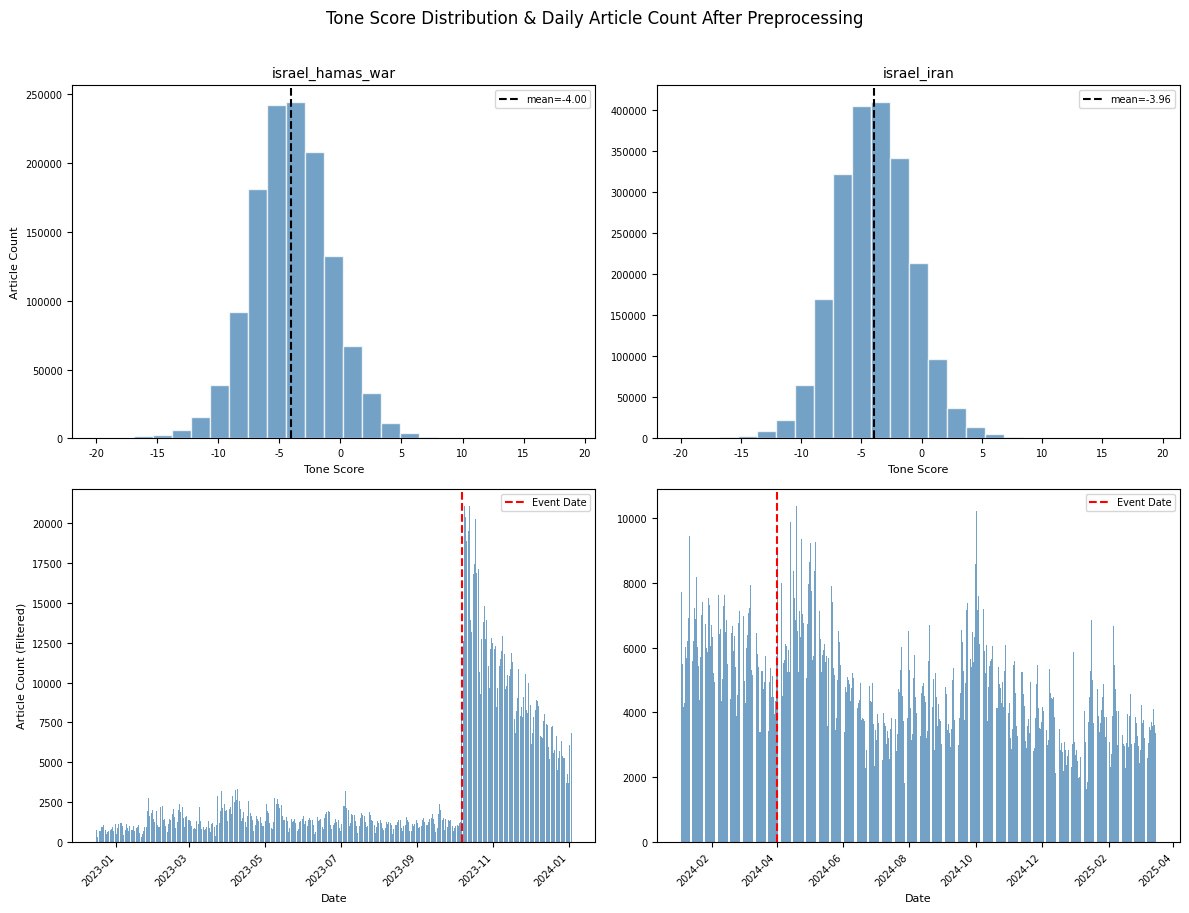

Saved: 02-3_israel_hamas_iran_preprocessed.png


In [15]:
if clean_dfs:
    n_ev=len(clean_dfs)
    fig,axes=plt.subplots(2,n_ev,figsize=(6*n_ev,9),squeeze=False)

    for col_i,(event,df) in enumerate(clean_dfs.items()):
        color=COLORS.get(event,'steelblue')

        ax0=axes[0,col_i]
        ax0.hist(df['tone_score'],bins=25,color=color,alpha=0.75,edgecolor='white')
        ax0.axvline(df['tone_score'].mean(),color='black',lw=1.5,ls='--',label=f"mean={df['tone_score'].mean():.2f}")
        ax0.set_title(EVENT_LABELS.get(EVENT_NAME_MAP[event],event),fontsize=10)
        ax0.set_xlabel('Tone Score',fontsize=8)
        ax0.legend(fontsize=7)
        ax0.tick_params(axis='both',labelsize=7)
        if col_i==0:
            ax0.set_ylabel('Article Count',fontsize=8)
        ax1=axes[1,col_i]
        daily_cnt=df.groupby('_date').size()
        clean_event=EVENT_NAME_MAP[event]
        event_dt=pd.Timestamp(EVENT_DATES[clean_event])
        ax1.bar(daily_cnt.index,daily_cnt.values,color=color,alpha=0.75)
        ax1.axvline(event_dt,color='red',lw=1.5,ls='--',label='Event Date')
        ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
        ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
        plt.setp(ax1.xaxis.get_majorticklabels(),rotation=45,ha='right')
        ax1.set_xlabel('Date',fontsize=8)
        ax1.legend(fontsize=7)
        ax1.tick_params(axis='both',labelsize=7)
        if col_i==0:
            ax1.set_ylabel('Article Count (Filtered)',fontsize=8)

    plt.suptitle('Tone Score Distribution & Daily Article Count After Preprocessing',fontsize=12,y=1.01)
    plt.tight_layout()
    plt.savefig('02-3_israel_hamas_iran_preprocessed.png',dpi=150,bbox_inches='tight')
    plt.show()

    print('Saved: 02-3_israel_hamas_iran_preprocessed.png')

---
#### Step 2 - 3.  GPR 대체 지수 5종 산출

In [16]:
def compute_gpr_indices(df, event_name):
    df = df.dropna(subset=['tone_score','positive_score',
                            'negative_score','polarity']).copy()

    df['tone_x_polarity'] = df['tone_score'] * df['polarity']

    agg = df.groupby('_date').agg(
        N                   = ('tone_score',      'count'),
        mean_tone           = ('tone_score',      'mean'),
        sum_tone_x_polarity = ('tone_x_polarity', 'sum'),
        sum_polarity        = ('polarity',         'sum'),
        mean_pos            = ('positive_score',  'mean'),
        mean_neg            = ('negative_score',  'mean'),
    ).copy()
    
    avg_n = agg['N'].mean()
    agg['relative_N'] = agg['N'] / avg_n
    agg['coverage_scaled'] = np.log1p(agg['relative_N'])

    agg['F1_raw'] = -agg['mean_tone']

    agg['F2_raw'] = np.where(
        agg['sum_polarity'] > 0,
        -agg['sum_tone_x_polarity'] / agg['sum_polarity'],
        np.nan)

    agg['F3_raw'] = -agg['mean_tone'] * agg['coverage_scaled']

    denom = agg['mean_pos'] + agg['mean_neg']
    agg['F4_raw'] = np.where(denom > 1e-6, agg['mean_neg'] / denom, np.nan)

    r, WND = 0.1, 28
    raw_w   = np.array([(1 - r) ** k for k in range(WND)])
    weights = raw_w / raw_w.sum()

    def ewma_28(series):
        result = np.full(len(series), np.nan)
        arr    = series.values
        for i in range(len(arr)):
            window = arr[max(0, i - WND + 1): i + 1][::-1]
            w_cut  = weights[:len(window)]
            w_cut  = w_cut / w_cut.sum()
            valid  = ~np.isnan(window)
            if valid.sum() > 0:
                result[i] = (np.nansum(window[valid] * w_cut[valid])
                             / w_cut[valid].sum())
        return pd.Series(result, index=series.index)

    agg = agg.sort_index()
    agg['F5_raw'] = ewma_28(agg['F2_raw'])

    for f in ['F1','F2','F3','F4','F5']:
        col = f'{f}_raw'
        mu, sig = agg[col].mean(), agg[col].std()
        agg[f'{f}_z'] = (agg[col] - mu) / sig if sig > 0 else np.nan

    clean_event_name = EVENT_NAME_MAP[event_name]

    agg['event_name'] = clean_event_name
    agg['event_date'] = EVENT_DATES[clean_event_name]
    return agg.reset_index().rename(columns={'_date': 'date'})


gpr_results = {}
print('▶ GPR 대체 지수 5종 산출\n')
print(f'{"이벤트":<30} {"유효일":>6} {"F1 mean":>9} {"F2 mean":>9} {"F3 mean":>9}')
print('-' * 70)
for event, df in clean_dfs.items():
    result = compute_gpr_indices(df, event)
    gpr_results[event] = result
    print(f"{event:<30} {len(result):>6} "
          f"{result['F1_raw'].mean():>9.3f} "
          f"{result['F2_raw'].mean():>9.3f} "
          f"{result['F3_raw'].mean():>9.3f}")
gpr_all = pd.concat(gpr_results.values(), ignore_index=True)
print(f'\n산출 완료: 총 {len(gpr_all)}행')

▶ GPR 대체 지수 5종 산출

이벤트                               유효일   F1 mean   F2 mean   F3 mean
----------------------------------------------------------------------
israel_hamas_raw                  384     3.445     4.097     2.167
israel_iran_raw                   438     3.955     4.496     2.687

산출 완료: 총 822행


In [17]:
output_filename = 'gpr_israel_hamas_iran.csv'

gpr_all.to_csv(output_filename, index=False, encoding='utf-8-sig')

print(f'✅ 저장 완료: {output_filename}')

✅ 저장 완료: gpr_israel_hamas_iran.csv


### (4) us_israel_iran

#### Step 2 - 1. CSV 로드 + 데이터 이해

In [4]:
fs = gcsfs.GCSFileSystem()

cols_to_use = [
    'event_timestamp', 'event_date', 'url', 'tone_score', 
    'positive_score', 'negative_score', 'polarity', 'themes'
]

all_war_data = {}
war_list = ['us_israel_iran_raw']

for war in war_list:
    path = f'gs://{war}/{war}_*'  
    files = fs.glob(path)
    
    if files:
        try:
            temp_df = pd.concat(
                [pd.read_csv(f"gs://{f}", usecols=cols_to_use) for f in files], 
                ignore_index=True
            )
            if 'event_date' in temp_df.columns:
                temp_df.rename(columns={'event_date': 'date'}, inplace=True)
            temp_df['event_label'] = war
            
            all_war_data[war] = temp_df
            print(f"✅ {war} 로드 완료: {len(temp_df)} 행")
        except Exception as e:
            print(f"❌ {war} 로드 중 오류 발생: {e}")

if all_war_data:
    total_war_df = pd.concat(all_war_data.values(), ignore_index=True)
    total_war_df = total_war_df.sort_values(by='event_timestamp', ascending=True).reset_index(drop=True)
    print(f"\n🚀 최종 통합 완료! 전체 행 개수: {len(total_war_df)}")
    display(total_war_df.head())
else:
    print("로드된 데이터가 없습니다.")

✅ us_israel_iran_raw 로드 완료: 367297 행

🚀 최종 통합 완료! 전체 행 개수: 367297


,event_timestamp,date,url,tone_score,positive_score,negative_score,polarity,themes,event_label
0,2025-03-17 00:00:00 UTC,2025-03-17,https://www.courant.com/2025/03/16/us-iran-esc...,-5.856515,1.317716,7.174231,8.491947,"TAX_FNCACT_SPOKESPERSON,2435;TAX_ETHNICITY_ARA...",us_israel_iran_raw
1,2025-03-17 00:00:00 UTC,2025-03-17,https://www.bostonglobe.com/2025/03/16/world/u...,-5.188679,1.415094,6.603774,8.018868,"BAN,371;TAX_WORLDMAMMALS_FOX,1172;EPU_POLICY_W...",us_israel_iran_raw
2,2025-03-17 00:00:00 UTC,2025-03-17,https://www.yahoo.com/news/fifty-three-killed-...,-4.930663,1.848998,6.779661,8.628659,"EPU_CATS_NATIONAL_SECURITY,989;EPU_CATS_NATION...",us_israel_iran_raw
3,2025-03-17 00:15:00 UTC,2025-03-17,https://www.aa.com.tr/en/middle-east/houthis-c...,-5.079365,1.269841,6.349206,7.619048,"MEDIA_MSM,1850;ARMEDCONFLICT,160;ARMEDCONFLICT...",us_israel_iran_raw
4,2025-03-17 00:30:00 UTC,2025-03-17,https://www.mymotherlode.com/news/world/364968...,-5.992949,1.057579,7.050529,8.108108,"TAX_WEAPONS_CRUISE_MISSILE,4684;TAX_FNCACT_LEA...",us_israel_iran_raw


In [5]:
if 'total_war_df' in locals() and not total_war_df.empty:
    print(f'▶ 통합 데이터 탐색 진행\n')
    
    print('기간:', total_war_df["date"].min(), '~', total_war_df["date"].max())
    print('전체 행수:', len(total_war_df))
    print()
    
    print('결측치 합계:')
    print(total_war_df.isnull().sum())
    
    print('\n수치형 컬럼 기술통계:')
    stats_cols = ['tone_score', 'positive_score', 'negative_score', 'polarity']
    display(total_war_df[stats_cols].describe().round(3))
else:
    print('탐색할 데이터프레임(total_war_df)이 존재하지 않습니다.')

▶ 통합 데이터 탐색 진행

기간: 2025-03-17 ~ 2026-04-30
전체 행수: 367297

결측치 합계:
event_timestamp    0
date               0
url                0
tone_score         0
positive_score     0
negative_score     0
polarity           0
themes             0
event_label        0
dtype: int64

수치형 컬럼 기술통계:


,tone_score,positive_score,negative_score,polarity
count,367297.000,367297.000,367297.000,367297.000
mean,-3.478,2.095,5.573,7.667
std,2.419,1.112,1.974,2.101
min,-23.529,0.000,0.000,0.000
25%,-4.986,1.362,4.241,6.278
50%,-3.544,1.932,5.491,7.550
75%,-2.033,2.630,6.767,8.925
max,13.323,14.943,24.902,27.255


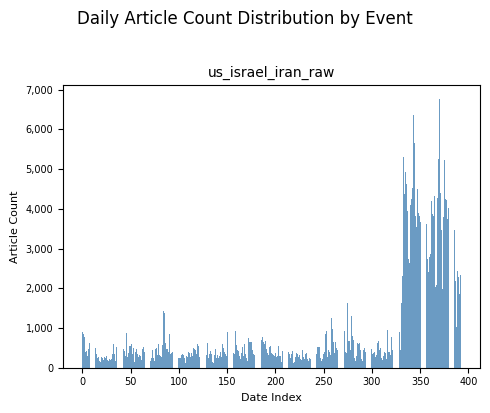

Saved: 01-4_us_israel_iran_iran_article_count.png


In [6]:
if all_war_data:
    n_raw=len(all_war_data)
    fig,axes=plt.subplots(1,n_raw,figsize=(5*n_raw,4))
    if n_raw==1: axes=[axes]

    for ax,(event,df) in zip(axes,all_war_data.items()):
        daily_cnt=df.groupby('date').size().sort_index()
        dates_list=daily_cnt.index.tolist()

        ax.bar(range(len(daily_cnt)),daily_cnt.values,color=COLORS.get(event,'steelblue'),alpha=0.8)

        event_origin_date=EVENT_DATES.get(event)

        if event_origin_date in dates_list:
            event_idx=dates_list.index(event_origin_date)

            ax.axvline(x=event_idx,color='red',linestyle='--',linewidth=1.5,label='Event Date')

            ax.text(event_idx,ax.get_ylim()[1]*0.9,'Event Date',color='red',fontsize=8,ha='center',va='bottom')

        ax.set_title(EVENT_LABELS.get(event,event),fontsize=10)
        ax.set_xlabel('Date Index',fontsize=8)
        ax.set_ylabel('Article Count',fontsize=8)
        ax.tick_params(axis='both',labelsize=7)

        ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x,_: f'{int(x):,}'))

    plt.suptitle('Daily Article Count Distribution by Event',fontsize=12,y=1.02)
    plt.tight_layout()
    plt.savefig('01-4_us_israel_iran_article_count.png',dpi=150,bbox_inches='tight')
    plt.show()

    print('Saved: 01-4_us_israel_iran_iran_article_count.png')

else:
    print('No available data in all_war_data')

#### Step 2 - 2. 데이터 전처리

In [8]:
MIN_DAILY_COUNT    = 5
TONE_OUTLIER_BOUND = 20

def has_geo_theme(themes_str):
    if pd.isna(themes_str) or themes_str == '':
        return False
    return any(tag in themes_str for tag in GEO_THEMES)

def preprocess(df, event_name):
    log = {'event': event_name, 'raw': len(df)}
    df  = df.copy()

    df = df.drop_duplicates(subset=['url'])
    log['after_dedup'] = len(df)

    df = df.dropna(subset=['tone_score','positive_score',
                            'negative_score','polarity'])
    log['after_tone_na'] = len(df)

    df = df[df['tone_score'].abs() <= TONE_OUTLIER_BOUND]
    log['after_outlier'] = len(df)

    for col in ['themes']:
        df[col] = df[col].fillna('')

    df['event_timestamp'] = pd.to_datetime(df['event_timestamp'])
    df['_date'] = df['event_timestamp'].dt.tz_convert(None).dt.normalize()

    df = df[df['themes'].apply(has_geo_theme)]
    log['after_geo_filter'] = len(df)

    daily_cnt   = df.groupby('_date').size()
    valid_dates = daily_cnt[daily_cnt >= MIN_DAILY_COUNT].index
    df = df[df['_date'].isin(valid_dates)]
    log['after_min_count'] = len(df)
    log['valid_days']      = df['_date'].nunique()

    return df, log

clean_dfs = {}
logs = []
print('▶ 데이터 전처리\n')
header = (f'{"이벤트":<30} {"raw":>8} {"중복제거":>8} '
          f'{"이상값":>8} {"지정학":>8} {"최소건수":>8} {"유효일":>6}')
print(header)
print('-' * len(header))
for label, group_df in total_war_df.groupby('event_label'):
    cleaned, log = preprocess(group_df, label)
    
    clean_dfs[label] = cleaned
    logs.append(log)

    print(f"{label:<30} "
          f"{log['raw']:>8,} {log['after_dedup']:>8,} "
          f"{log['after_outlier']:>8,} {log['after_geo_filter']:>8,} "
          f"{log['after_min_count']:>8,} {log['valid_days']:>6}")

preprocess_log_df = pd.DataFrame(logs)
print(f'\n✨ 전처리 완료: {len(clean_dfs)}개 이벤트')

▶ 데이터 전처리

이벤트                                 raw     중복제거      이상값      지정학     최소건수    유효일
----------------------------------------------------------------------------------
us_israel_iran_raw              367,297  367,297  367,293  367,293  367,293    393

✨ 전처리 완료: 1개 이벤트


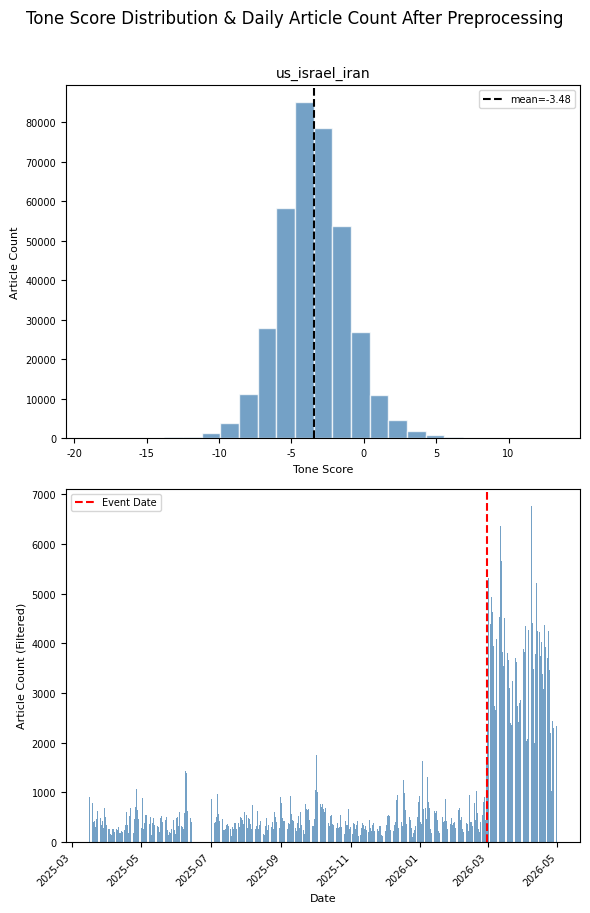

Saved: 02-4_us_israel_iran_preprocessed.png


In [9]:
if clean_dfs:
    n_ev=len(clean_dfs)
    fig,axes=plt.subplots(2,n_ev,figsize=(6*n_ev,9),squeeze=False)

    for col_i,(event,df) in enumerate(clean_dfs.items()):
        color=COLORS.get(event,'steelblue')

        ax0=axes[0,col_i]
        ax0.hist(df['tone_score'],bins=25,color=color,alpha=0.75,edgecolor='white')
        ax0.axvline(df['tone_score'].mean(),color='black',lw=1.5,ls='--',label=f"mean={df['tone_score'].mean():.2f}")
        ax0.set_title(EVENT_LABELS.get(EVENT_NAME_MAP[event],event),fontsize=10)
        ax0.set_xlabel('Tone Score',fontsize=8)
        ax0.legend(fontsize=7)
        ax0.tick_params(axis='both',labelsize=7)
        if col_i==0:
            ax0.set_ylabel('Article Count',fontsize=8)
        ax1=axes[1,col_i]
        daily_cnt=df.groupby('_date').size()
        clean_event=EVENT_NAME_MAP[event]
        event_dt=pd.Timestamp(EVENT_DATES[clean_event])
        ax1.bar(daily_cnt.index,daily_cnt.values,color=color,alpha=0.75)
        ax1.axvline(event_dt,color='red',lw=1.5,ls='--',label='Event Date')
        ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
        ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
        plt.setp(ax1.xaxis.get_majorticklabels(),rotation=45,ha='right')
        ax1.set_xlabel('Date',fontsize=8)
        ax1.legend(fontsize=7)
        ax1.tick_params(axis='both',labelsize=7)
        if col_i==0:
            ax1.set_ylabel('Article Count (Filtered)',fontsize=8)

    plt.suptitle('Tone Score Distribution & Daily Article Count After Preprocessing',fontsize=12,y=1.01)
    plt.tight_layout()
    plt.savefig('02-4_us_israel_iran_preprocessed.png',dpi=150,bbox_inches='tight')
    plt.show()

    print('Saved: 02-4_us_israel_iran_preprocessed.png')

---
#### Step 2 - 3.  GPR 대체 지수 5종 산출

In [10]:
def compute_gpr_indices(df, event_name):
    df = df.dropna(subset=['tone_score','positive_score',
                            'negative_score','polarity']).copy()

    df['tone_x_polarity'] = df['tone_score'] * df['polarity']

    agg = df.groupby('_date').agg(
        N                   = ('tone_score',      'count'),
        mean_tone           = ('tone_score',      'mean'),
        sum_tone_x_polarity = ('tone_x_polarity', 'sum'),
        sum_polarity        = ('polarity',         'sum'),
        mean_pos            = ('positive_score',  'mean'),
        mean_neg            = ('negative_score',  'mean'),
    ).copy()
    
    avg_n = agg['N'].mean()
    agg['relative_N'] = agg['N'] / avg_n
    agg['coverage_scaled'] = np.log1p(agg['relative_N'])

    agg['F1_raw'] = -agg['mean_tone']

    agg['F2_raw'] = np.where(
        agg['sum_polarity'] > 0,
        -agg['sum_tone_x_polarity'] / agg['sum_polarity'],
        np.nan)

    agg['F3_raw'] = -agg['mean_tone'] * agg['coverage_scaled']

    denom = agg['mean_pos'] + agg['mean_neg']
    agg['F4_raw'] = np.where(denom > 1e-6, agg['mean_neg'] / denom, np.nan)

    r, WND = 0.1, 28
    raw_w   = np.array([(1 - r) ** k for k in range(WND)])
    weights = raw_w / raw_w.sum()

    def ewma_28(series):
        result = np.full(len(series), np.nan)
        arr    = series.values
        for i in range(len(arr)):
            window = arr[max(0, i - WND + 1): i + 1][::-1]
            w_cut  = weights[:len(window)]
            w_cut  = w_cut / w_cut.sum()
            valid  = ~np.isnan(window)
            if valid.sum() > 0:
                result[i] = (np.nansum(window[valid] * w_cut[valid])
                             / w_cut[valid].sum())
        return pd.Series(result, index=series.index)

    agg = agg.sort_index()
    agg['F5_raw'] = ewma_28(agg['F2_raw'])

    for f in ['F1','F2','F3','F4','F5']:
        col = f'{f}_raw'
        mu, sig = agg[col].mean(), agg[col].std()
        agg[f'{f}_z'] = (agg[col] - mu) / sig if sig > 0 else np.nan

    clean_event_name = EVENT_NAME_MAP[event_name]

    agg['event_name'] = clean_event_name
    agg['event_date'] = EVENT_DATES[clean_event_name]
    return agg.reset_index().rename(columns={'_date': 'date'})


gpr_results = {}
print('▶ GPR 대체 지수 5종 산출\n')
print(f'{"이벤트":<30} {"유효일":>6} {"F1 mean":>9} {"F2 mean":>9} {"F3 mean":>9}')
print('-' * 70)
for event, df in clean_dfs.items():
    result = compute_gpr_indices(df, event)
    gpr_results[event] = result
    print(f"{event:<30} {len(result):>6} "
          f"{result['F1_raw'].mean():>9.3f} "
          f"{result['F2_raw'].mean():>9.3f} "
          f"{result['F3_raw'].mean():>9.3f}")
gpr_all = pd.concat(gpr_results.values(), ignore_index=True)
print(f'\n산출 완료: 총 {len(gpr_all)}행')

▶ GPR 대체 지수 5종 산출

이벤트                               유효일   F1 mean   F2 mean   F3 mean
----------------------------------------------------------------------
us_israel_iran_raw                393     3.174     3.539     1.886

산출 완료: 총 393행


In [11]:
output_filename = 'gpr_us_israel_iran.csv'

gpr_all.to_csv(output_filename, index=False, encoding='utf-8-sig')

print(f'✅ 저장 완료: {output_filename}')

✅ 저장 완료: gpr_us_israel_iran.csv


### (5) 파일 통합

In [13]:
import pandas as pd

file_list = [
    'gpr_hormuz_soleimani.csv', 
    'gpr_russia_ukraine.csv', 
    'gpr_israel_hamas_iran.csv',
    'gpr_us_israel_iran.csv'
]

combined_list = []

print("📂 파일 로드 및 통합 시작...")

for file in file_list:
    try:
        df = pd.read_csv(file)
        combined_list.append(df)
        print(f"✅ {file} 로드 완료: {len(df):,} 행")
    except FileNotFoundError:
        print(f"❌ {file}을 찾을 수 없습니다. 파일명을 확인해 주세요.")

if combined_list:
    total_custom_gpr = pd.concat(combined_list, ignore_index=True)
    
    date_col = 'date' if 'date' in total_custom_gpr.columns else '_date'
    
    total_custom_gpr[date_col] = pd.to_datetime(total_custom_gpr[date_col])
    
    total_custom_gpr = total_custom_gpr.sort_values(by=['event_name', date_col]).reset_index(drop=True)

    output_name = 'custom_gpr_daily.csv'
    total_custom_gpr.to_csv(output_name, index=False, encoding='utf-8-sig')
    
    print(f"\n🚀 최종 통합 완료!")
    print(f"📍 파일 저장 위치: {output_name}")
    print(f"📍 전체 데이터 행수: {len(total_custom_gpr):,}")
    
    display(total_custom_gpr.head())
else:
    print("⚠️ 통합할 데이터가 없습니다.")

📂 파일 로드 및 통합 시작...
✅ gpr_hormuz_soleimani.csv 로드 완료: 704 행
✅ gpr_russia_ukraine.csv 로드 완료: 686 행
✅ gpr_israel_hamas_iran.csv 로드 완료: 822 행
✅ gpr_us_israel_iran.csv 로드 완료: 393 행

🚀 최종 통합 완료!
📍 파일 저장 위치: custom_gpr_daily.csv
📍 전체 데이터 행수: 2,605


,date,N,mean_tone,sum_tone_x_polarity,sum_polarity,mean_pos,mean_neg,relative_N,coverage_scaled,F1_raw,...,F3_raw,F4_raw,F5_raw,F1_z,F2_z,F3_z,F4_z,F5_z,event_name,event_date
0,2019-01-01,355,-2.591841,-7328.850565,2586.936870,2.347653,4.939494,0.293244,0.257154,2.591841,...,0.666503,0.677836,2.833023,-1.130248,-1.231285,-0.966705,-1.193955,-2.945109,hormuz_crisis,2019-06-13
1,2019-01-02,406,-3.543997,-12097.722364,3036.680832,1.967756,5.511753,0.335373,0.289210,3.543997,...,1.024960,0.736914,3.438728,0.181932,0.260926,-0.745422,0.250042,-1.018541,hormuz_crisis,2019-06-13
2,2019-01-03,1149,-4.970440,-56390.228088,10409.896034,2.044761,7.015201,0.949121,0.667378,4.970440,...,3.317164,0.774308,4.168712,2.147734,2.119147,0.669603,1.164053,1.303317,hormuz_crisis,2019-06-13
3,2019-01-04,599,-2.927567,-14089.868111,4249.211006,2.083137,5.010704,0.494798,0.401991,2.927567,...,1.176857,0.706346,3.920723,-0.667580,-0.605201,-0.651653,-0.497119,0.514540,hormuz_crisis,2019-06-13
4,2019-01-05,384,-2.662565,-7587.785887,2617.794011,2.077303,4.739869,0.317200,0.275508,2.662565,...,0.733558,0.695284,3.671112,-1.032782,-1.146331,-0.925310,-0.767501,-0.279397,hormuz_crisis,2019-06-13


---
## Step 3. 공식 GPR 로드


In [33]:
def load_official_gpr(path):
    if not os.path.exists(path):
        print(f' {path} 없음 → 공식 GPR 없이 진행 (F1 기준 내부 상관분석)')
        return None
    try:
        gpr_raw = pd.read_csv(path)
    except Exception:
        try:
            gpr_raw = pd.read_stata(path)
        except Exception as e:
            print(f'GPR 파일 로드 실패: {e}')
            return None

    print('컬럼 목록:', list(gpr_raw.columns))
    print(gpr_raw.head(3))

    date_col = next((c for c in gpr_raw.columns
                     if c.lower() in ['month','date','year','mon']), None)
    gpr_col  = next((c for c in gpr_raw.columns
                     if 'GPR' in c.upper()
                     and 'GPRT' not in c.upper()
                     and 'GPRA' not in c.upper()
                     and 'GPRH' not in c.upper()), None)

    if date_col is None or gpr_col is None:
        print(f'컬럼 탐지 실패 — date_col={date_col}, gpr_col={gpr_col}')
        print("수동 지정: date_col='<날짜컬럼>', gpr_col='<GPR컬럼>'")
        return None

    print(f'\n날짜 컬럼: {date_col}, GPR 컬럼: {gpr_col}')
    gpr_raw[date_col] = pd.to_datetime(gpr_raw[date_col], errors='coerce')
    gpr_raw[gpr_col] = pd.to_numeric(
    gpr_raw[gpr_col],
    errors='coerce'
)
    monthly = (
        gpr_raw[[date_col, gpr_col]].dropna()
        .rename(columns={date_col: 'month', gpr_col: 'GPR'})
        .set_index('month').sort_index()
    )
    daily_idx = pd.date_range(
        monthly.index.min(),
        monthly.index.max() + pd.offsets.MonthEnd(0),
        freq='D')
    daily = monthly.reindex(daily_idx).ffill()
    daily.index.name = 'date'
    daily['GPR_zscore'] = (
        (daily['GPR'] - daily['GPR'].mean()) / daily['GPR'].std())
    print(f'\n공식 GPR: {daily.index.min().date()} ~ {daily.index.max().date()}')
    return daily

gpr_daily = load_official_gpr(GPR_FILE)

컬럼 목록: ['month', 'GPR', 'GPRT', 'GPRA', 'GPRH', 'GPRHT', 'GPRHA', 'SHARE_GPR', 'N10', 'SHARE_GPRH', 'N3H', 'GPRH_NOEW', 'GPR_NOEW', 'GPRH_AND', 'GPR_AND', 'GPRH_BASIC', 'GPR_BASIC', 'SHAREH_CAT_1', 'SHAREH_CAT_2', 'SHAREH_CAT_3', 'SHAREH_CAT_4', 'SHAREH_CAT_5', 'SHAREH_CAT_6', 'SHAREH_CAT_7', 'SHAREH_CAT_8', 'GPRC_ARG', 'GPRC_AUS', 'GPRC_BEL', 'GPRC_BRA', 'GPRC_CAN', 'GPRC_CHE', 'GPRC_CHL', 'GPRC_CHN', 'GPRC_COL', 'GPRC_DEU', 'GPRC_DNK', 'GPRC_EGY', 'GPRC_ESP', 'GPRC_FIN', 'GPRC_FRA', 'GPRC_GBR', 'GPRC_HKG', 'GPRC_HUN', 'GPRC_IDN', 'GPRC_IND', 'GPRC_ISR', 'GPRC_ITA', 'GPRC_JPN', 'GPRC_KOR', 'GPRC_MEX', 'GPRC_MYS', 'GPRC_NLD', 'GPRC_NOR', 'GPRC_PER', 'GPRC_PHL', 'GPRC_POL', 'GPRC_PRT', 'GPRC_RUS', 'GPRC_SAU', 'GPRC_SWE', 'GPRC_THA', 'GPRC_TUN', 'GPRC_TUR', 'GPRC_TWN', 'GPRC_UKR', 'GPRC_USA', 'GPRC_VEN', 'GPRC_VNM', 'GPRC_ZAF', 'GPRHC_ARG', 'GPRHC_AUS', 'GPRHC_BEL', 'GPRHC_BRA', 'GPRHC_CAN', 'GPRHC_CHE', 'GPRHC_CHL', 'GPRHC_CHN', 'GPRHC_COL', 'GPRHC_DEU', 'GPRHC_DNK', 'GPRHC_EGY', 'GPRHC

---
## Step 4. 공식 GPR과 상관관계 분석


In [70]:
custom_gpr = pd.read_csv('custom_gpr_daily.csv')

custom_gpr['date'] = pd.to_datetime(custom_gpr['date'])

def merge_with_official_gpr(result_df, gpr_daily_df):
    if gpr_daily_df is None:
        return result_df
    gpr_ref = gpr_daily_df[['GPR','GPR_zscore']].copy()
    gpr_ref.index = pd.to_datetime(gpr_ref.index)
    result_df = result_df.copy()
    result_df['date'] = pd.to_datetime(result_df['date'])
    result_df = result_df.set_index('date').join(gpr_ref, how='left')
    return result_df.reset_index()


def correlation_analysis(result_df, event_name, gpr_available):
    rows           = []
    formula_cols_z = ['F1_z','F2_z','F3_z','F4_z','F5_z']

    if gpr_available and 'GPR_zscore' in result_df.columns:
        ref_label    = 'GPR 공식 (Z-score)'
        target_col   = 'GPR_zscore'
        compare_cols = formula_cols_z
    else:
        ref_label    = 'F1_z (기준)'
        target_col   = 'F1_z'
        compare_cols = formula_cols_z[1:] 

    for f_col in compare_cols:
        pair = result_df[[f_col, target_col]].dropna()
        if len(pair) < 5:
            rows.append({'formula': f_col, 'n': len(pair),
                         'pearson_r': np.nan, 'pearson_p': np.nan,
                         'spearman_r': np.nan, 'spearman_p': np.nan})
            continue
        pr, pp = stats.pearsonr(pair[f_col], pair[target_col])
        sr, sp = stats.spearmanr(pair[f_col], pair[target_col])
        rows.append({'formula': f_col, 'n': len(pair),
                     'pearson_r': pr, 'pearson_p': pp,
                     'spearman_r': sr, 'spearman_p': sp})

    corr_df = pd.DataFrame(rows)
    corr_df['event']    = event_name
    corr_df['ref']      = ref_label
    corr_df['sig_5pct'] = corr_df['pearson_p'].apply(
        lambda p: '✅' if (pd.notna(p) and p < 0.05) else '—')
    return corr_df


gpr_available  = gpr_daily is not None
merged_results = {}

for event, result in custom_gpr.groupby('event_name'):
    merged_results[event] = merge_with_official_gpr(result, gpr_daily)

all_corr = []
print(f'▶ 상관관계 분석 ({"공식 GPR 기준" if gpr_available else "F1 기준"})\n')
for event, result in merged_results.items():
    corr_df = correlation_analysis(result, event, gpr_available)
    all_corr.append(corr_df)
    print(f'  [{EVENT_LABELS.get(event, event)}]')
    print(corr_df[['formula','n','pearson_r','pearson_p',
                    'spearman_r','spearman_p','sig_5pct']].to_string(index=False))
    print()

corr_summary = pd.concat(all_corr, ignore_index=True) if all_corr else pd.DataFrame()

▶ 상관관계 분석 (공식 GPR 기준)

  [hormuz_crisis]
formula   n  pearson_r    pearson_p  spearman_r   spearman_p sig_5pct
   F1_z 266   0.184931 2.461098e-03    0.209937 5.682629e-04        ✅
   F2_z 266   0.132295 3.100591e-02    0.158656 9.545956e-03        ✅
   F3_z 266   0.331834 2.948795e-08    0.400840 1.092752e-11        ✅
   F4_z 266   0.194360 1.445436e-03    0.194564 1.428505e-03        ✅
   F5_z 266   0.379695 1.504316e-10    0.436606 8.312628e-14        ✅

  [israel_hamas_war]
formula   n  pearson_r     pearson_p  spearman_r   spearman_p sig_5pct
   F1_z 384   0.392040  1.475236e-15    0.425661 2.482041e-18        ✅
   F2_z 384   0.296479  3.131114e-09    0.348895 1.964737e-12        ✅
   F3_z 384   0.837561 2.505932e-102    0.576033 2.530987e-35        ✅
   F4_z 384   0.379424  1.352576e-14    0.406119 1.109740e-16        ✅
   F5_z 384   0.414926  2.064512e-17    0.458700 2.234031e-21        ✅

  [israel_iran]
formula   n  pearson_r    pearson_p  spearman_r   spearman_p sig_5pct
   F

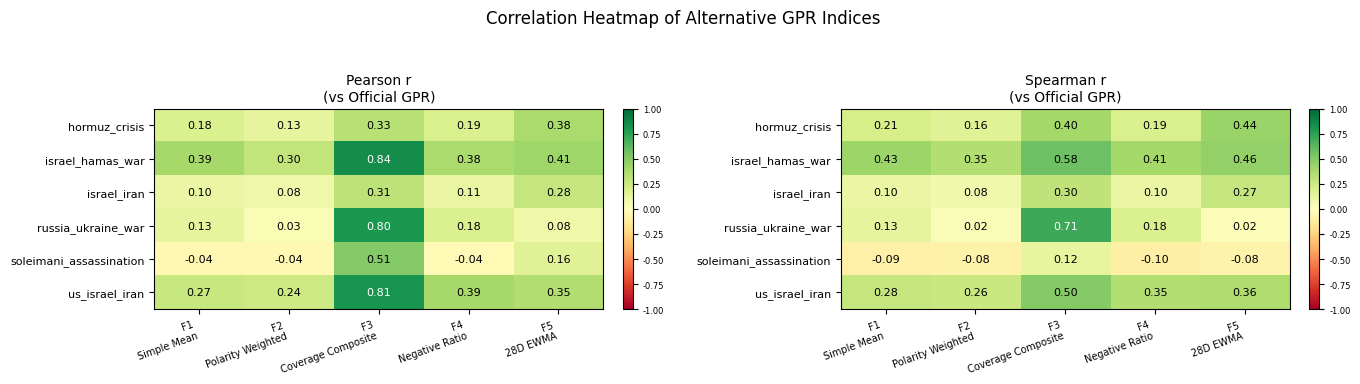

Saved: 03_correlation_heatmap.png


In [77]:
formula_cols_z = ['F1_z','F2_z','F3_z','F4_z','F5_z']

formula_labels = [
    'F1\nSimple Mean',
    'F2\nPolarity Weighted',
    'F3\nCoverage Composite',
    'F4\nNegative Ratio',
    'F5\n28D EWMA'
]

if corr_summary.empty:

    print('No correlation data → skipped')

else:

    fig, axes = plt.subplots(1, 2, figsize=(14, max(4, len(gpr_results) * 1.2 + 2)))

    for ax_i, (metric, metric_label) in enumerate([
        ('pearson_r', 'Pearson r'),
        ('spearman_r', 'Spearman r')
    ]):

        ax = axes[ax_i]

        pivot = corr_summary.pivot_table(
            index='event',
            columns='formula',
            values=metric,
            aggfunc='first'
        )

        pivot = pivot.reindex(columns=[c for c in formula_cols_z if c in pivot.columns])

        im = ax.imshow(
            pivot.values.astype(float),
            cmap='RdYlGn',
            vmin=-1,
            vmax=1,
            aspect='auto'
        )

        cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        cbar.ax.tick_params(labelsize=6)

        ax.set_xticks(range(pivot.shape[1]))
        ax.set_xticklabels([formula_labels[formula_cols_z.index(c)] for c in pivot.columns], fontsize=7, rotation=20, ha='right')

        ax.set_yticks(range(pivot.shape[0]))
        ax.set_yticklabels([EVENT_LABELS.get(e, e) for e in pivot.index], fontsize=8)

        ax.set_title(
            f'{metric_label}\n({"vs Official GPR" if gpr_available else "vs F1"})',
            fontsize=10
        )

        for row in range(pivot.shape[0]):
            for col in range(pivot.shape[1]):

                val = pivot.values[row, col]

                if pd.notna(val):

                    ax.text(
                        col,
                        row,
                        f'{val:.2f}',
                        ha='center',
                        va='center',
                        fontsize=8,
                        color='white' if abs(val) > 0.6 else 'black'
                    )

    plt.suptitle('Correlation Heatmap of Alternative GPR Indices', fontsize=12)

    plt.tight_layout()

    plt.savefig('03_correlation_heatmap.png', dpi=150, bbox_inches='tight')

    plt.show()

    print('Saved: 03_correlation_heatmap.png')

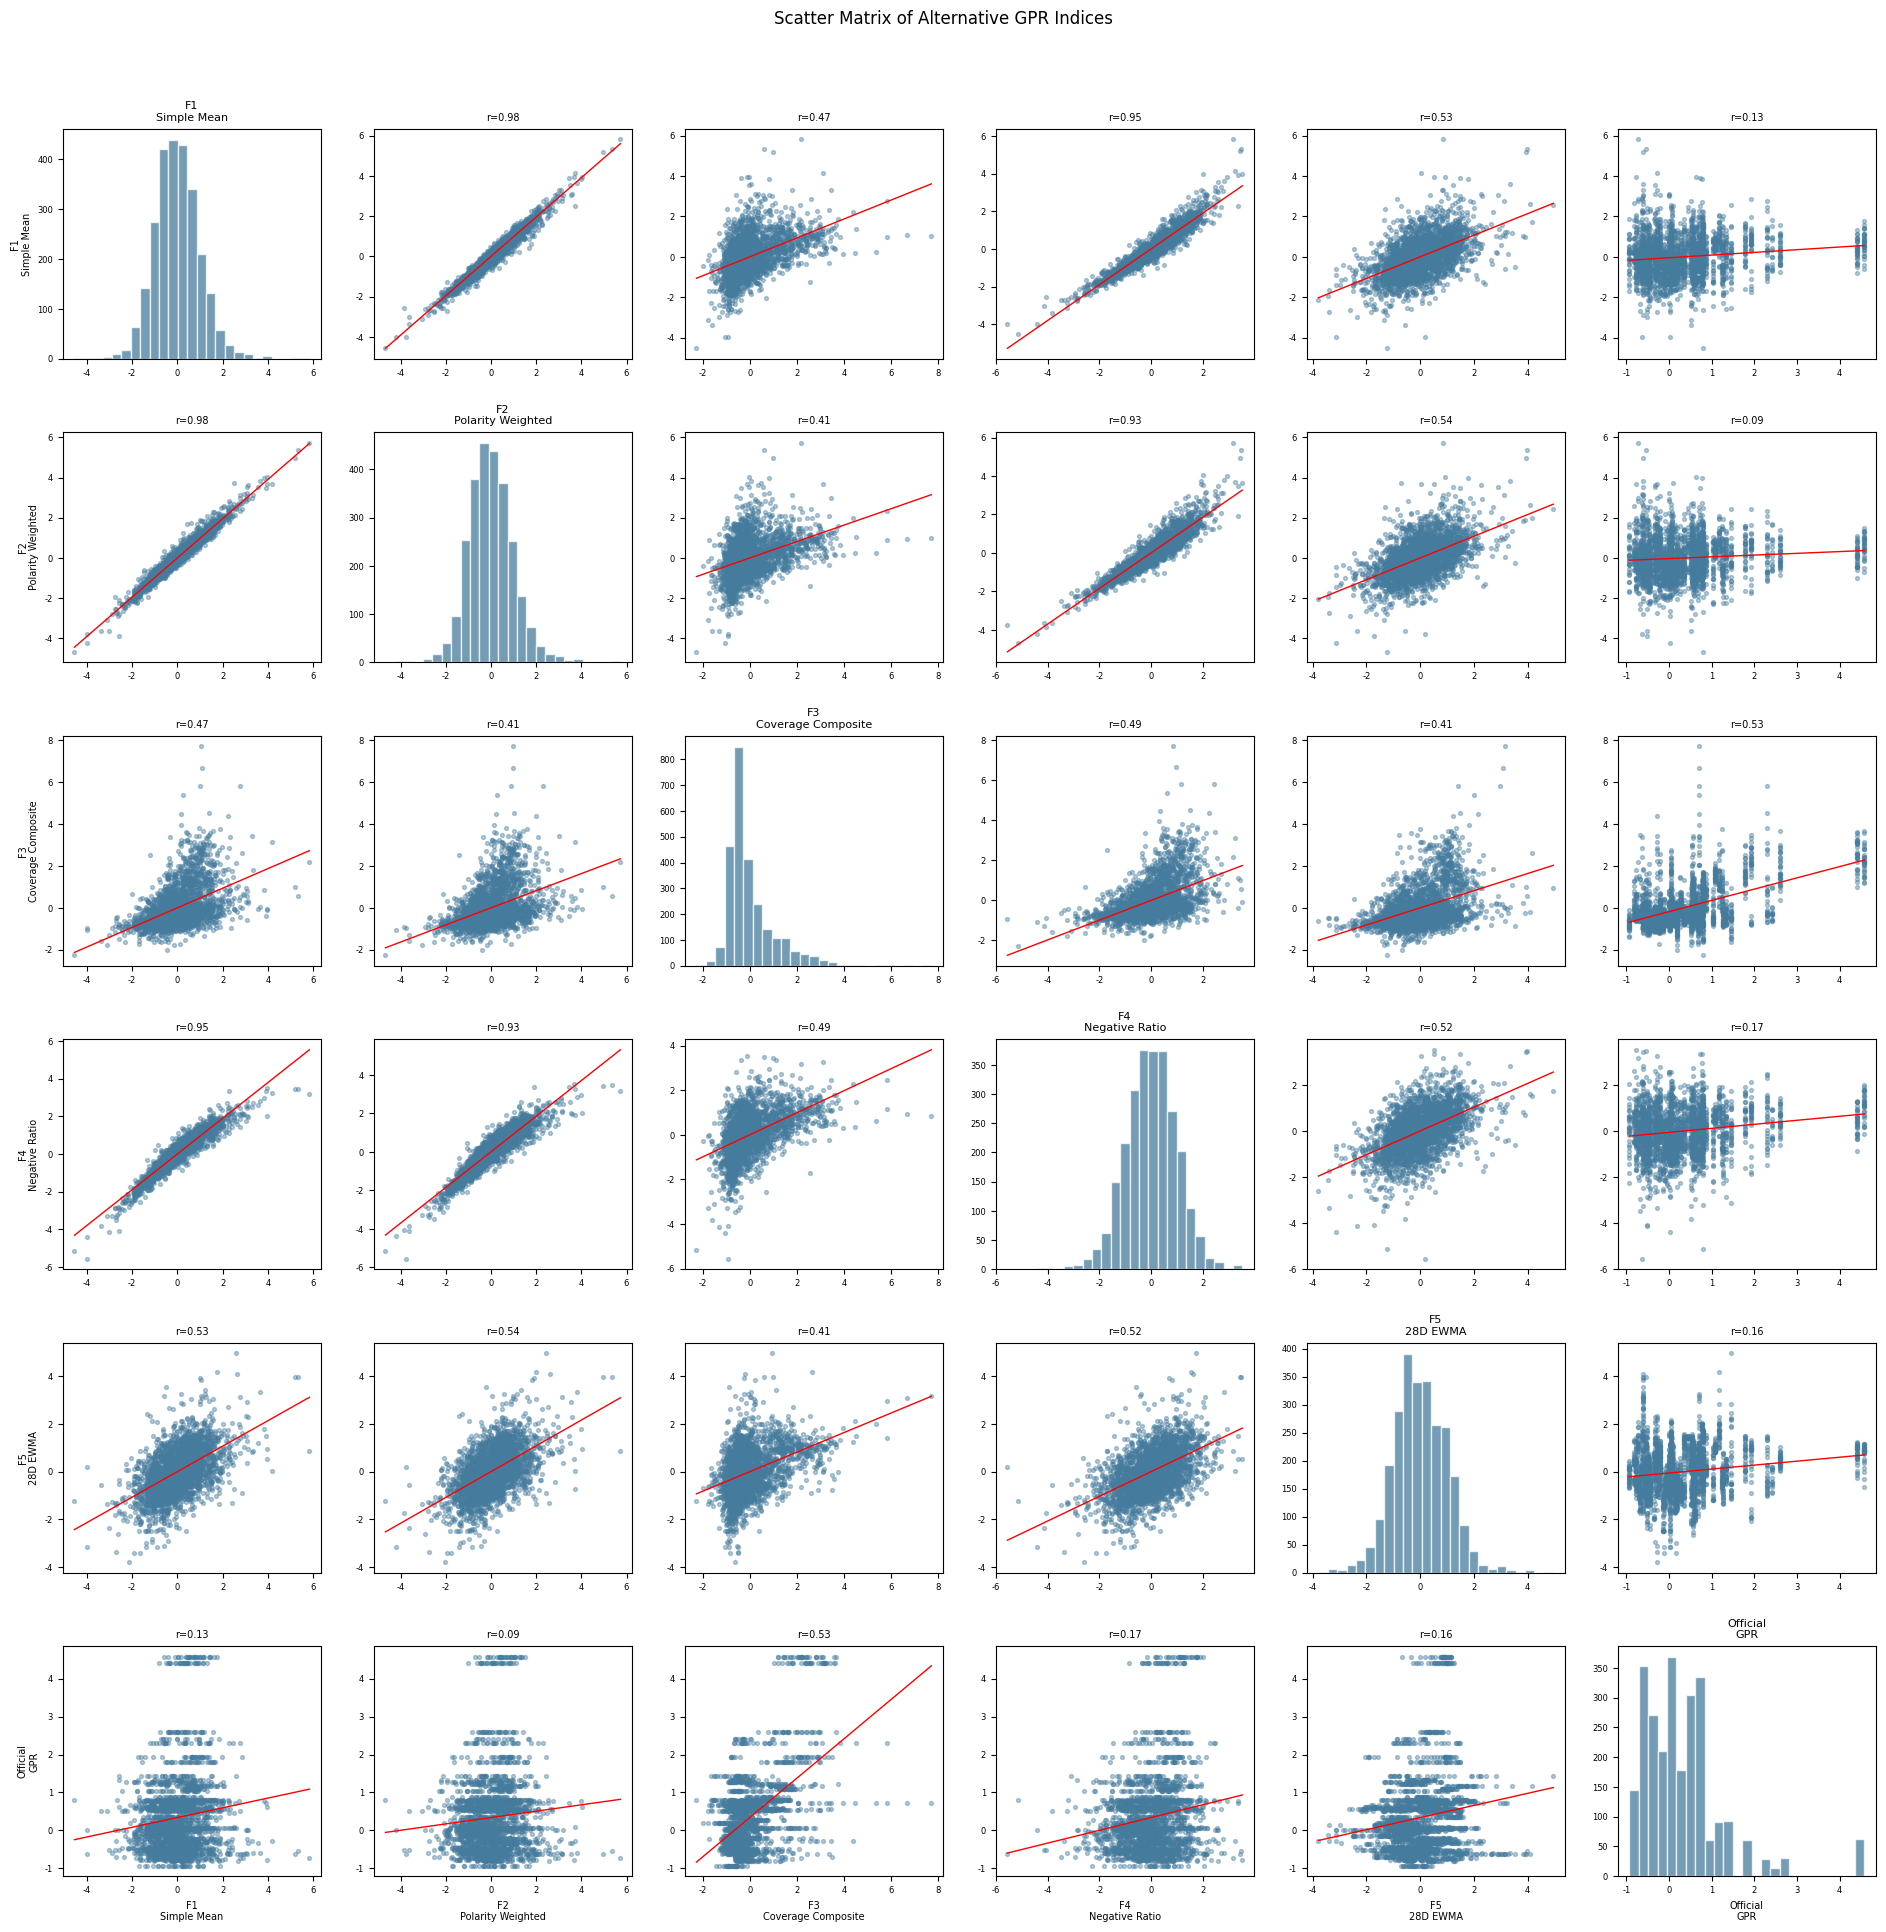

Saved: 04_scatter_matrix.png


In [78]:
z_cols = ['F1_z','F2_z','F3_z','F4_z','F5_z']

all_merged = pd.concat(merged_results.values(), ignore_index=True)

if gpr_available and 'GPR_zscore' in all_merged.columns:
    scatter_cols = z_cols + ['GPR_zscore']
    scatter_labels = [
        'F1\nSimple Mean',
        'F2\nPolarity Weighted',
        'F3\nCoverage Composite',
        'F4\nNegative Ratio',
        'F5\n28D EWMA',
        'Official\nGPR'
    ]
else:
    scatter_cols = z_cols
    scatter_labels = [
        'F1\nSimple Mean',
        'F2\nPolarity Weighted',
        'F3\nCoverage Composite',
        'F4\nNegative Ratio',
        'F5\n28D EWMA'
    ]

n_sc = len(scatter_cols)
fig, axes = plt.subplots(n_sc, n_sc, figsize=(3.2 * n_sc, 3.2 * n_sc))
for i, (ci, li) in enumerate(zip(scatter_cols, scatter_labels)):
    for j, (cj, lj) in enumerate(zip(scatter_cols, scatter_labels)):
        ax = axes[i, j]
        if i == j:
            data = all_merged[ci].dropna()
            ax.hist(data, bins=25, color='#457B9D', alpha=0.75, edgecolor='white')
            ax.set_title(li, fontsize=8)

        else:
            xy = all_merged[[ci, cj]].dropna()
            if len(xy) > 2:

                ax.scatter(
                    xy[cj],
                    xy[ci],
                    s=8,
                    alpha=0.4,
                    color='#457B9D'
                )

                m, b = np.polyfit(xy[cj], xy[ci], 1)
                xr = np.linspace(xy[cj].min(), xy[cj].max(), 50)
                ax.plot(xr, m * xr + b, 'r-', lw=1)
                r, _ = stats.pearsonr(xy[ci], xy[cj])
                ax.set_title(f'r={r:.2f}', fontsize=7)
                
        if i == n_sc - 1:
            ax.set_xlabel(lj, fontsize=7)
            
        if j == 0:
            ax.set_ylabel(li, fontsize=7)
        ax.tick_params(labelsize=6)

plt.suptitle('Scatter Matrix of Alternative GPR Indices', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('04_scatter_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print('Saved: 04_scatter_matrix.png')

---
## Step 5. 시각화


### Step 5-1. 이벤트별 F1~F5 시계열

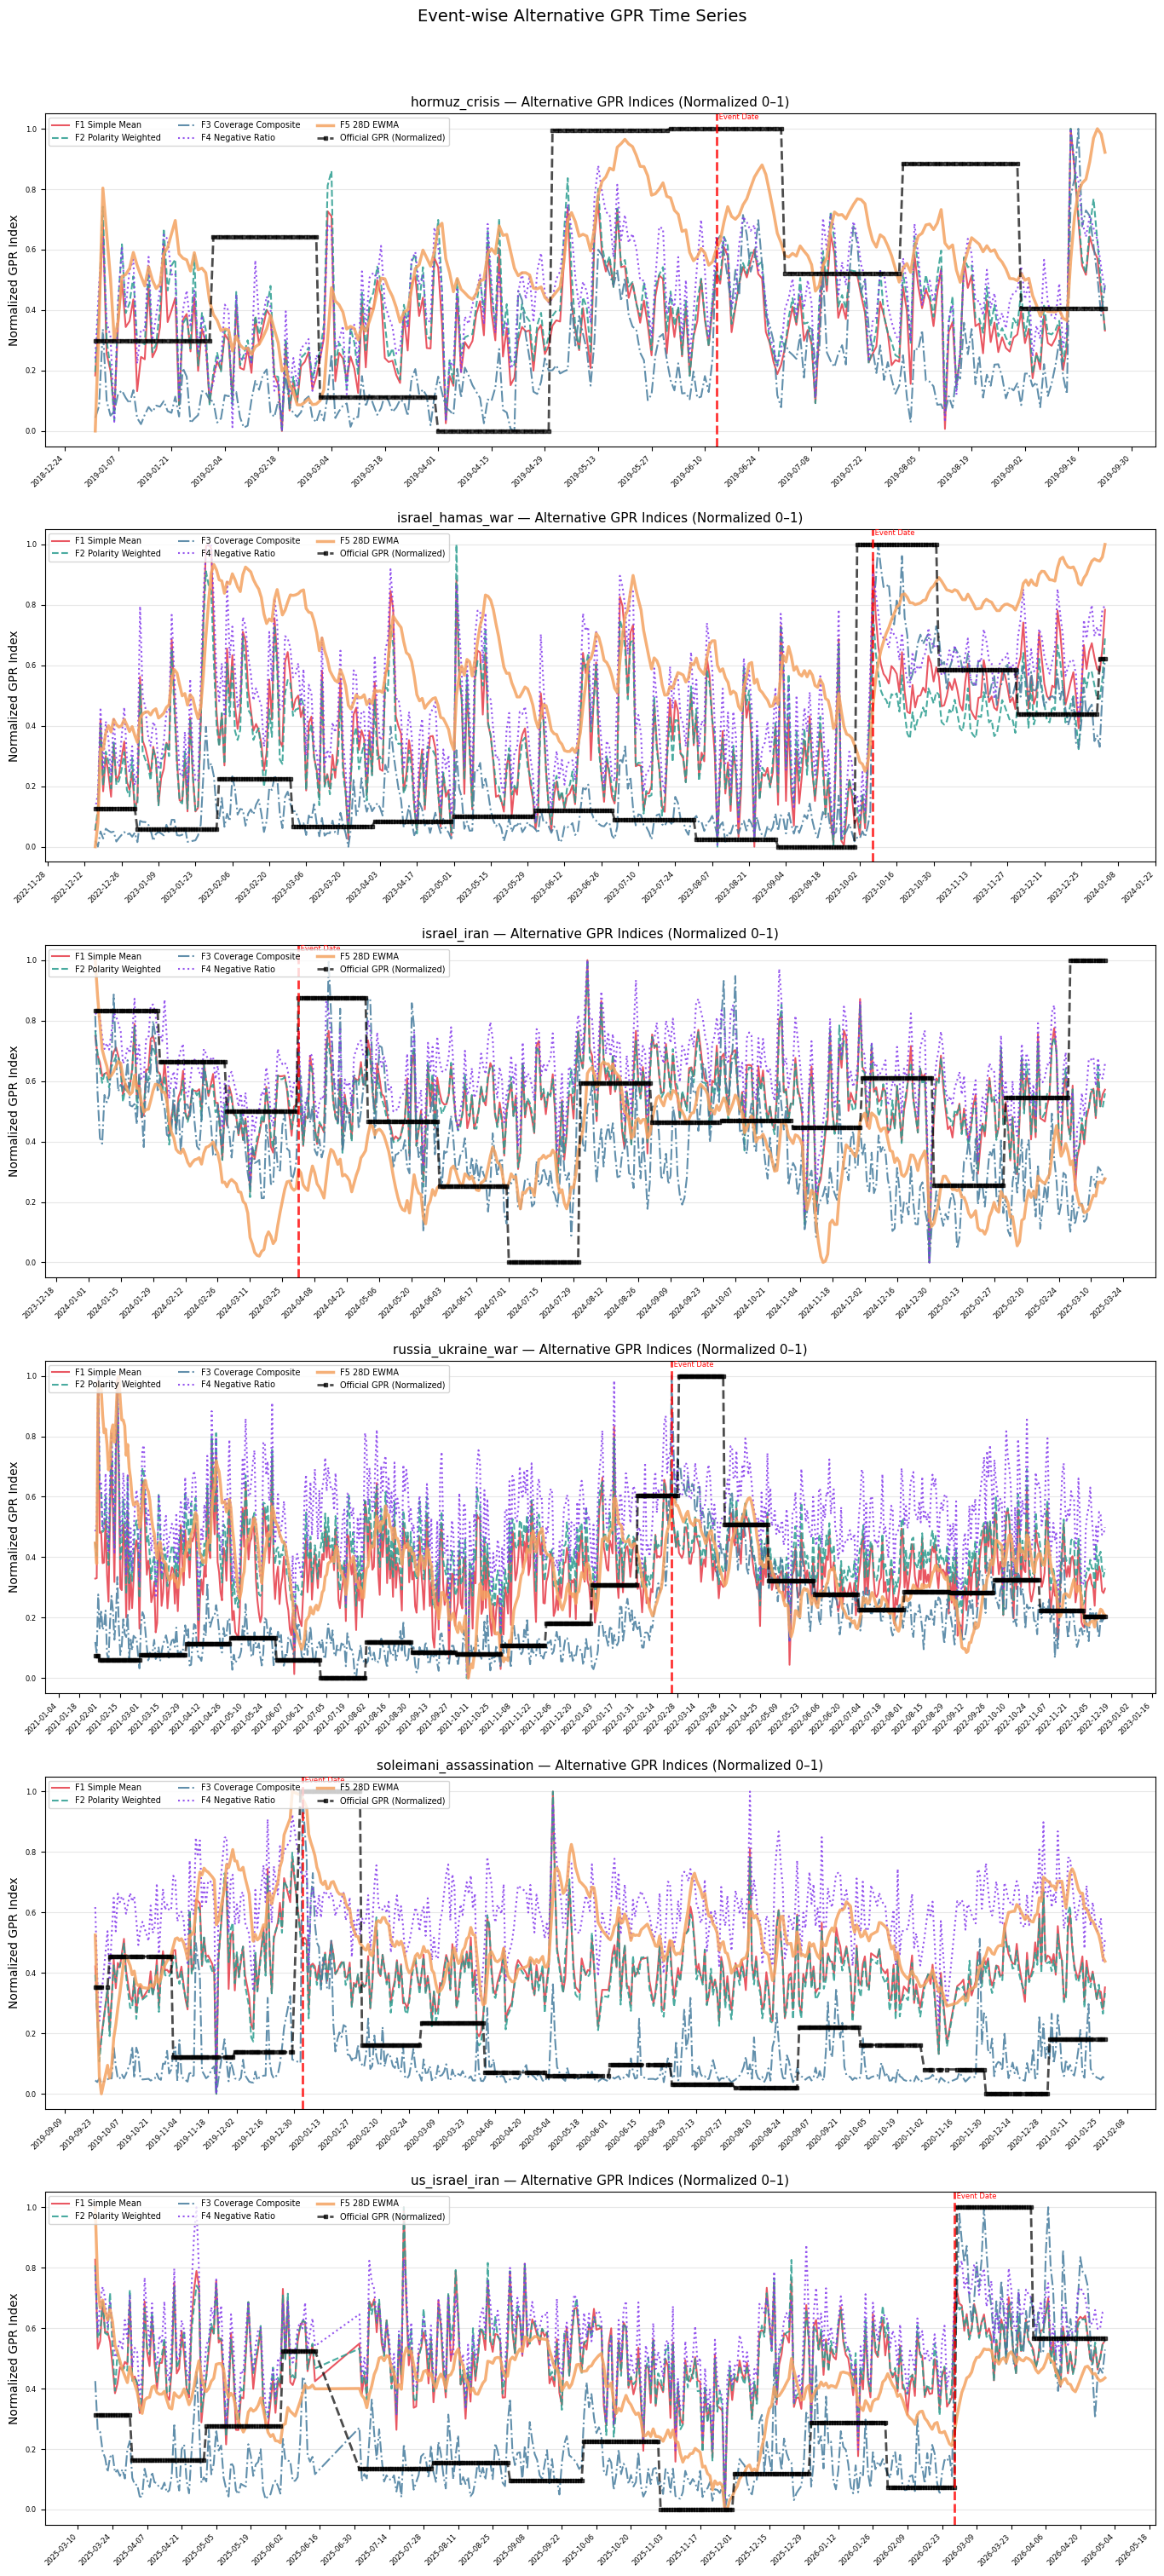

Saved: 05_gpr_timeseries.png


In [66]:
raw_cols   = ['F1_raw','F2_raw','F3_raw','F4_raw','F5_raw']
raw_styles = [ ('-','#E63946'), ('--','#2A9D8F'), ('-.','#457B9D'), (':','#8338EC'), ('-','#F4A261') ]

raw_widths = [1.5, 1.5, 1.5, 1.5, 2.5]

raw_labels = [
    'F1 Simple Mean',
    'F2 Polarity Weighted',
    'F3 Coverage Composite',
    'F4 Negative Ratio',
    'F5 28D EWMA'
]
n_events = len(merged_results)
fig, axes = plt.subplots( n_events, 1, figsize=(14, 5 * n_events), sharex=False )
if n_events == 1:
    axes = [axes]

for ax, (event, result) in zip(axes, merged_results.items()):

    result = result.copy()
    result['date'] = pd.to_datetime(result['date'])
    result = result.sort_values('date')

    event_dt = pd.Timestamp(EVENT_DATES[event])

    for col in raw_cols:
        mn, mx = result[col].min(), result[col].max()
        result[col + '_norm'] = (
            (result[col] - mn) / (mx - mn)
            if mx > mn else 0.5
        )

    for (ls, clr), lw, lbl, col in zip(
        raw_styles,
        raw_widths,
        raw_labels,
        raw_cols
    ):

        ax.plot(
            result['date'],
            result[col + '_norm'],
            ls=ls,
            color=clr,
            lw=lw,
            label=lbl,
            alpha=0.85
        )

    if gpr_available and 'GPR_zscore' in result.columns:
        gpr_sub = result[['date', 'GPR_zscore']].dropna()
        if len(gpr_sub) > 0:
            mn, mx = (
                gpr_sub['GPR_zscore'].min(),
                gpr_sub['GPR_zscore'].max()
            )
            gpr_norm = (
                (gpr_sub['GPR_zscore'] - mn) / (mx - mn)
                if mx > mn else 0.5
            )
            ax.plot(
                gpr_sub['date'],
                gpr_norm,
                's--',
                color='black',
                lw=2,
                ms=3,
                label='Official GPR (Normalized)',
                alpha=0.7
            )

    # Event date
    ax.axvline(
        event_dt,
        color='red',
        lw=2,
        ls='--',
        alpha=0.8
    )

    ax.text(
        event_dt,
        1.0,
        ' Event Date',
        color='red',
        fontsize=6,
        va='top',
        transform=ax.get_xaxis_transform()
    )

    ax.set_title(f'{EVENT_LABELS.get(event, event)} — Alternative GPR Indices (Normalized 0–1)', fontsize=11)

    ax.set_ylabel('Normalized GPR Index', fontsize=10)
    ax.tick_params(axis='both', labelsize=6)

    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0, interval=2))
    
    plt.setp(
        ax.xaxis.get_majorticklabels(),
        rotation=45,
        ha='right' )
    ax.legend(
        fontsize=7,
        loc='upper left',
        ncol=3)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle(
    'Event-wise Alternative GPR Time Series',
    fontsize=14,
    y=1.01
)
plt.tight_layout()
plt.savefig( '05_gpr_timeseries.png', dpi=150, bbox_inches='tight' )
plt.show()

print('Saved: 05_gpr_timeseries.png')

### Step 5-2. 공식 GPR vs 우리 지수 직접 비교

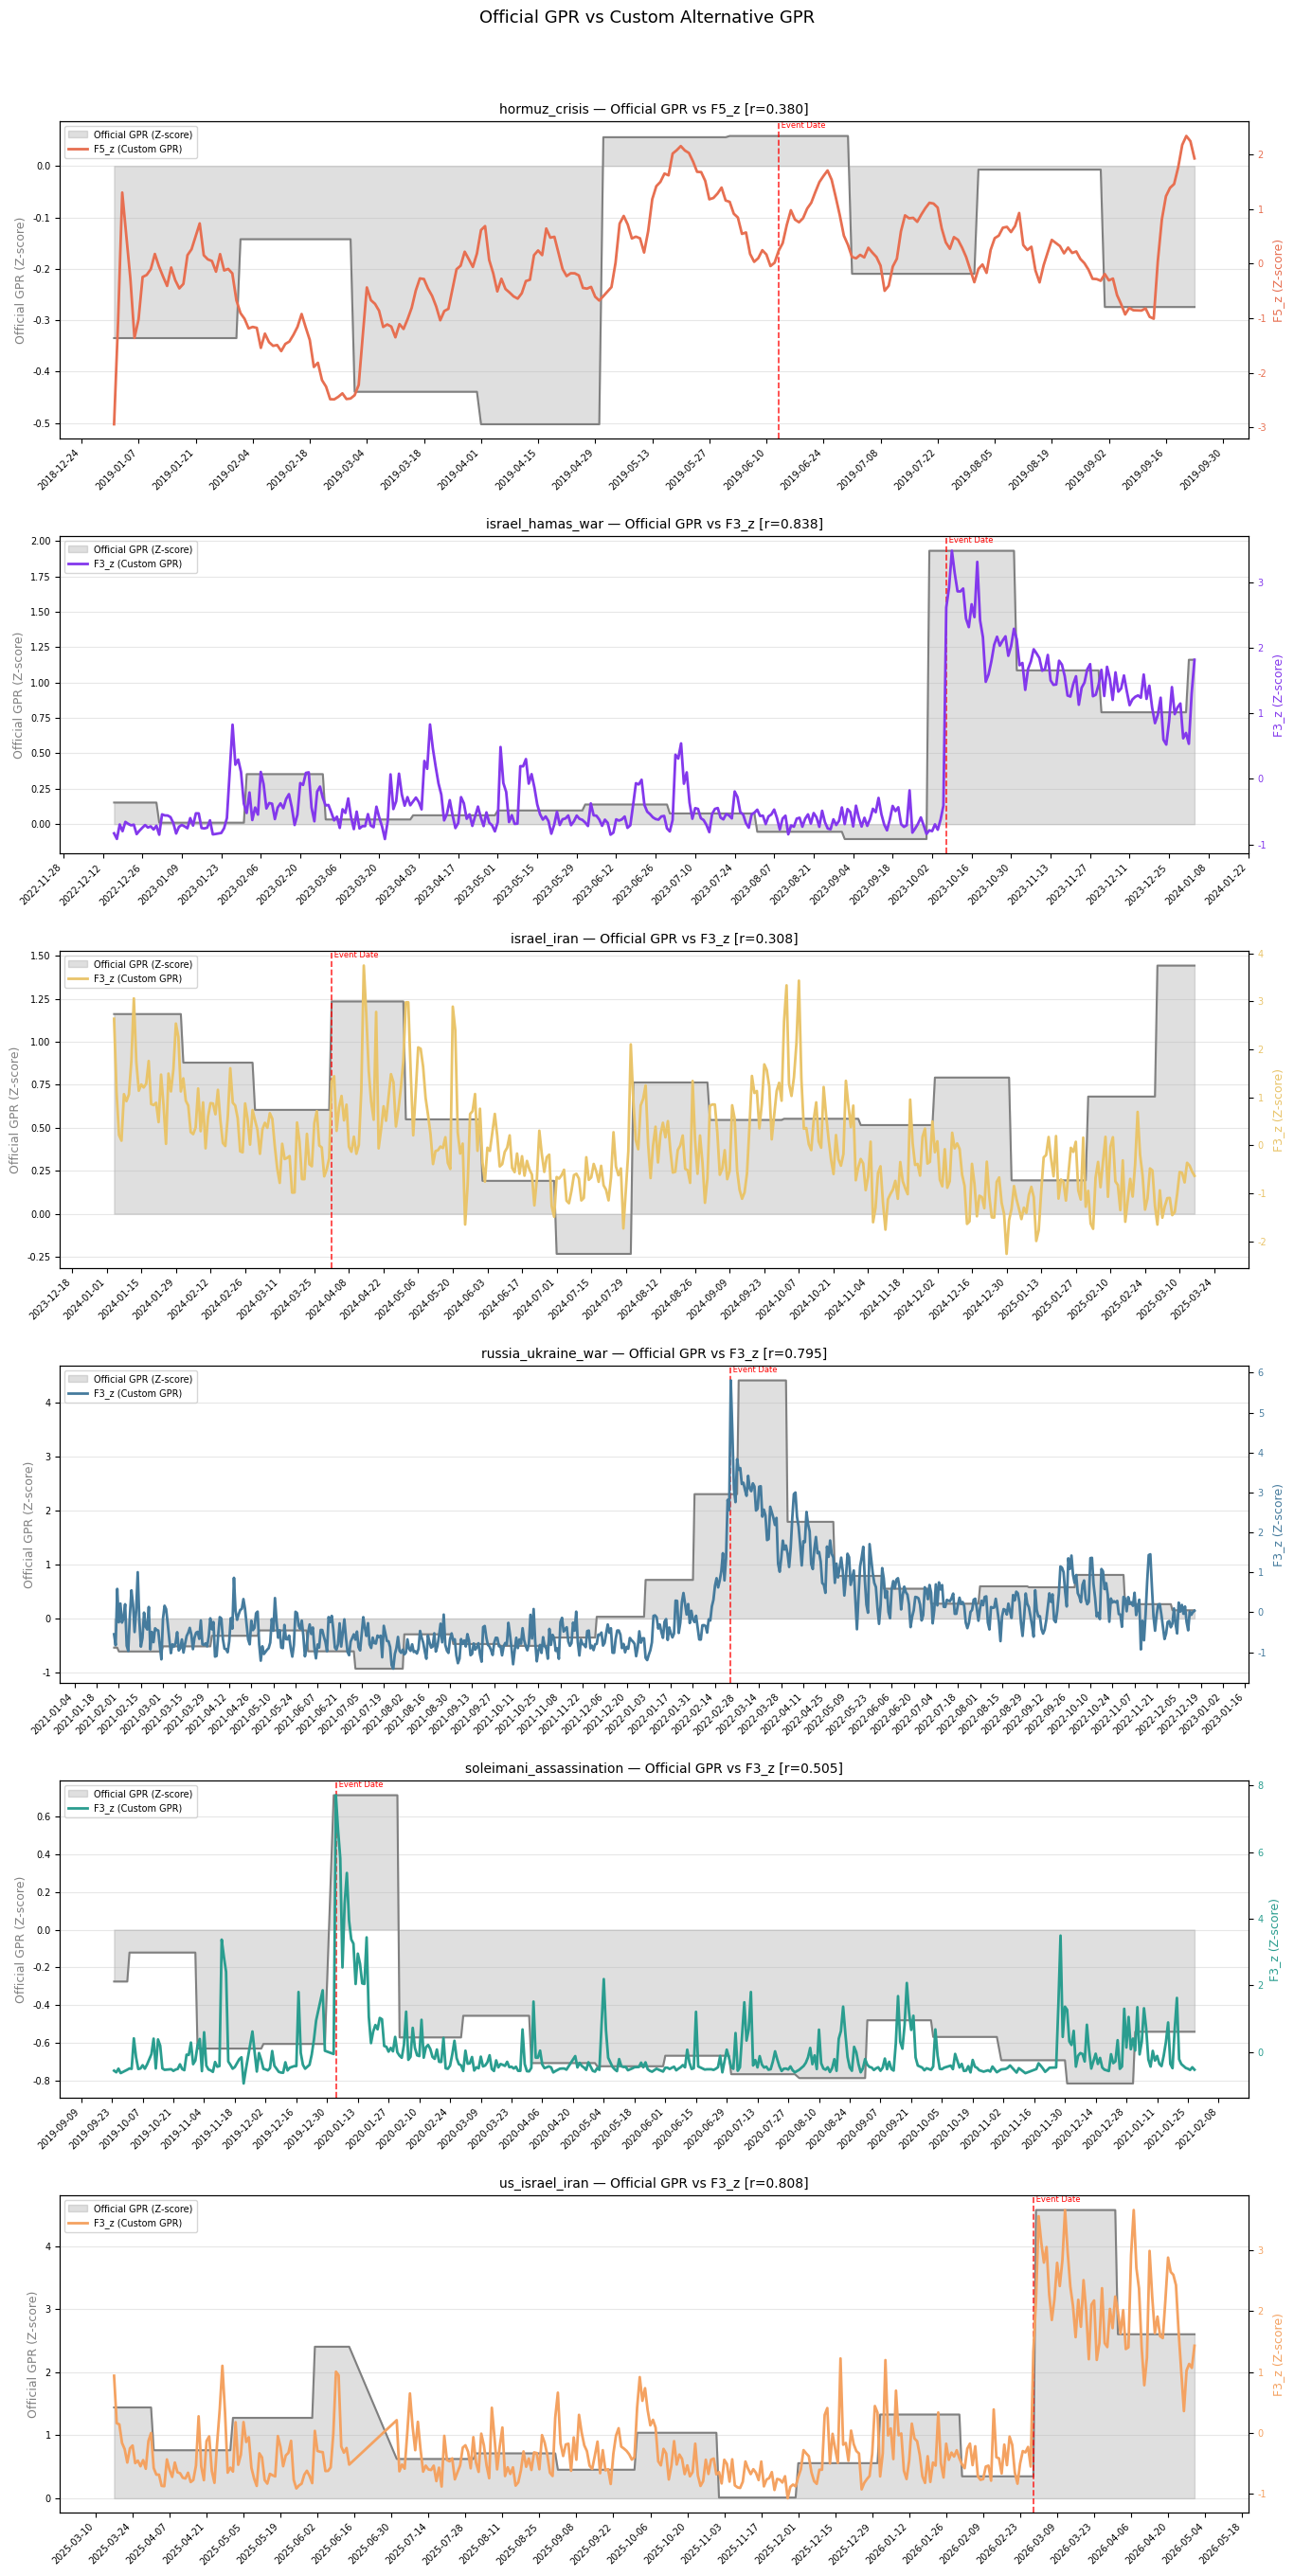

Saved: 06_official_vs_ours.png


In [67]:
if gpr_available:

    n_events = len(merged_results)
    fig, axes = plt.subplots(n_events, 1, figsize=(14, 4.5 * n_events))
    if n_events == 1: axes = [axes]

    best_formula = corr_summary.loc[corr_summary.groupby('event')['pearson_r'].idxmax()].set_index('event')['formula'] if not corr_summary.empty else pd.Series(dtype=str)

    for ax, (event, result) in zip(axes, merged_results.items()):

        result = result.copy()
        result['date'] = pd.to_datetime(result['date'])
        result = result.sort_values('date')

        event_dt = pd.Timestamp(EVENT_DATES[event])
        color = COLORS.get(event, 'steelblue')
        best = best_formula.get(event, 'F2_z')

        ax2 = ax.twinx()

        gpr_sub = result[['date','GPR_zscore']].dropna()

        ax.fill_between(gpr_sub['date'], gpr_sub['GPR_zscore'], alpha=0.25, color='gray', label='Official GPR (Z-score)')
        ax.plot(gpr_sub['date'], gpr_sub['GPR_zscore'], color='gray', lw=1.5)
        ax.set_ylabel('Official GPR (Z-score)', color='gray', fontsize=9)

        our_sub = result[['date', best]].dropna()

        ax2.plot(our_sub['date'], our_sub[best], color=color, lw=2, label=f'{best} (Custom GPR)')
        ax2.set_ylabel(f'{best} (Z-score)', color=color, fontsize=9)
        ax2.tick_params(axis='y', labelcolor=color, labelsize=7)

        r_row = corr_summary.loc[(corr_summary['event'] == event) & (corr_summary['formula'] == best), 'pearson_r']
        r_str = f'r={r_row.values[0]:.3f}' if len(r_row) > 0 else ''

        ax.set_title(f'{EVENT_LABELS.get(event, event)} — Official GPR vs {best} [{r_str}]', fontsize=10)

        ax.axvline(event_dt, color='red', lw=1.2, ls='--', alpha=0.8)

        ax.text(event_dt, 1.0, ' Event Date', color='red', fontsize=6, va='top', transform=ax.get_xaxis_transform())

        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
        ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0, interval=2))

        plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

        ax.tick_params(axis='both', labelsize=7)

        lines1, labels1 = ax.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()

        ax.legend(lines1 + lines2, labels1 + labels2, fontsize=7, loc='upper left')

        ax.grid(axis='y', alpha=0.3)

    plt.suptitle('Official GPR vs Custom Alternative GPR', fontsize=13, y=1.01)

    plt.tight_layout()

    plt.savefig('06_official_vs_ours.png', dpi=150, bbox_inches='tight')

    plt.show()

    print('Saved: 06_official_vs_ours.png')

else:
    print('Official GPR file not found → skipped')

### Step 5-3. 이벤트 전후 ±26일 GPR 변화 (이벤트 스터디형)

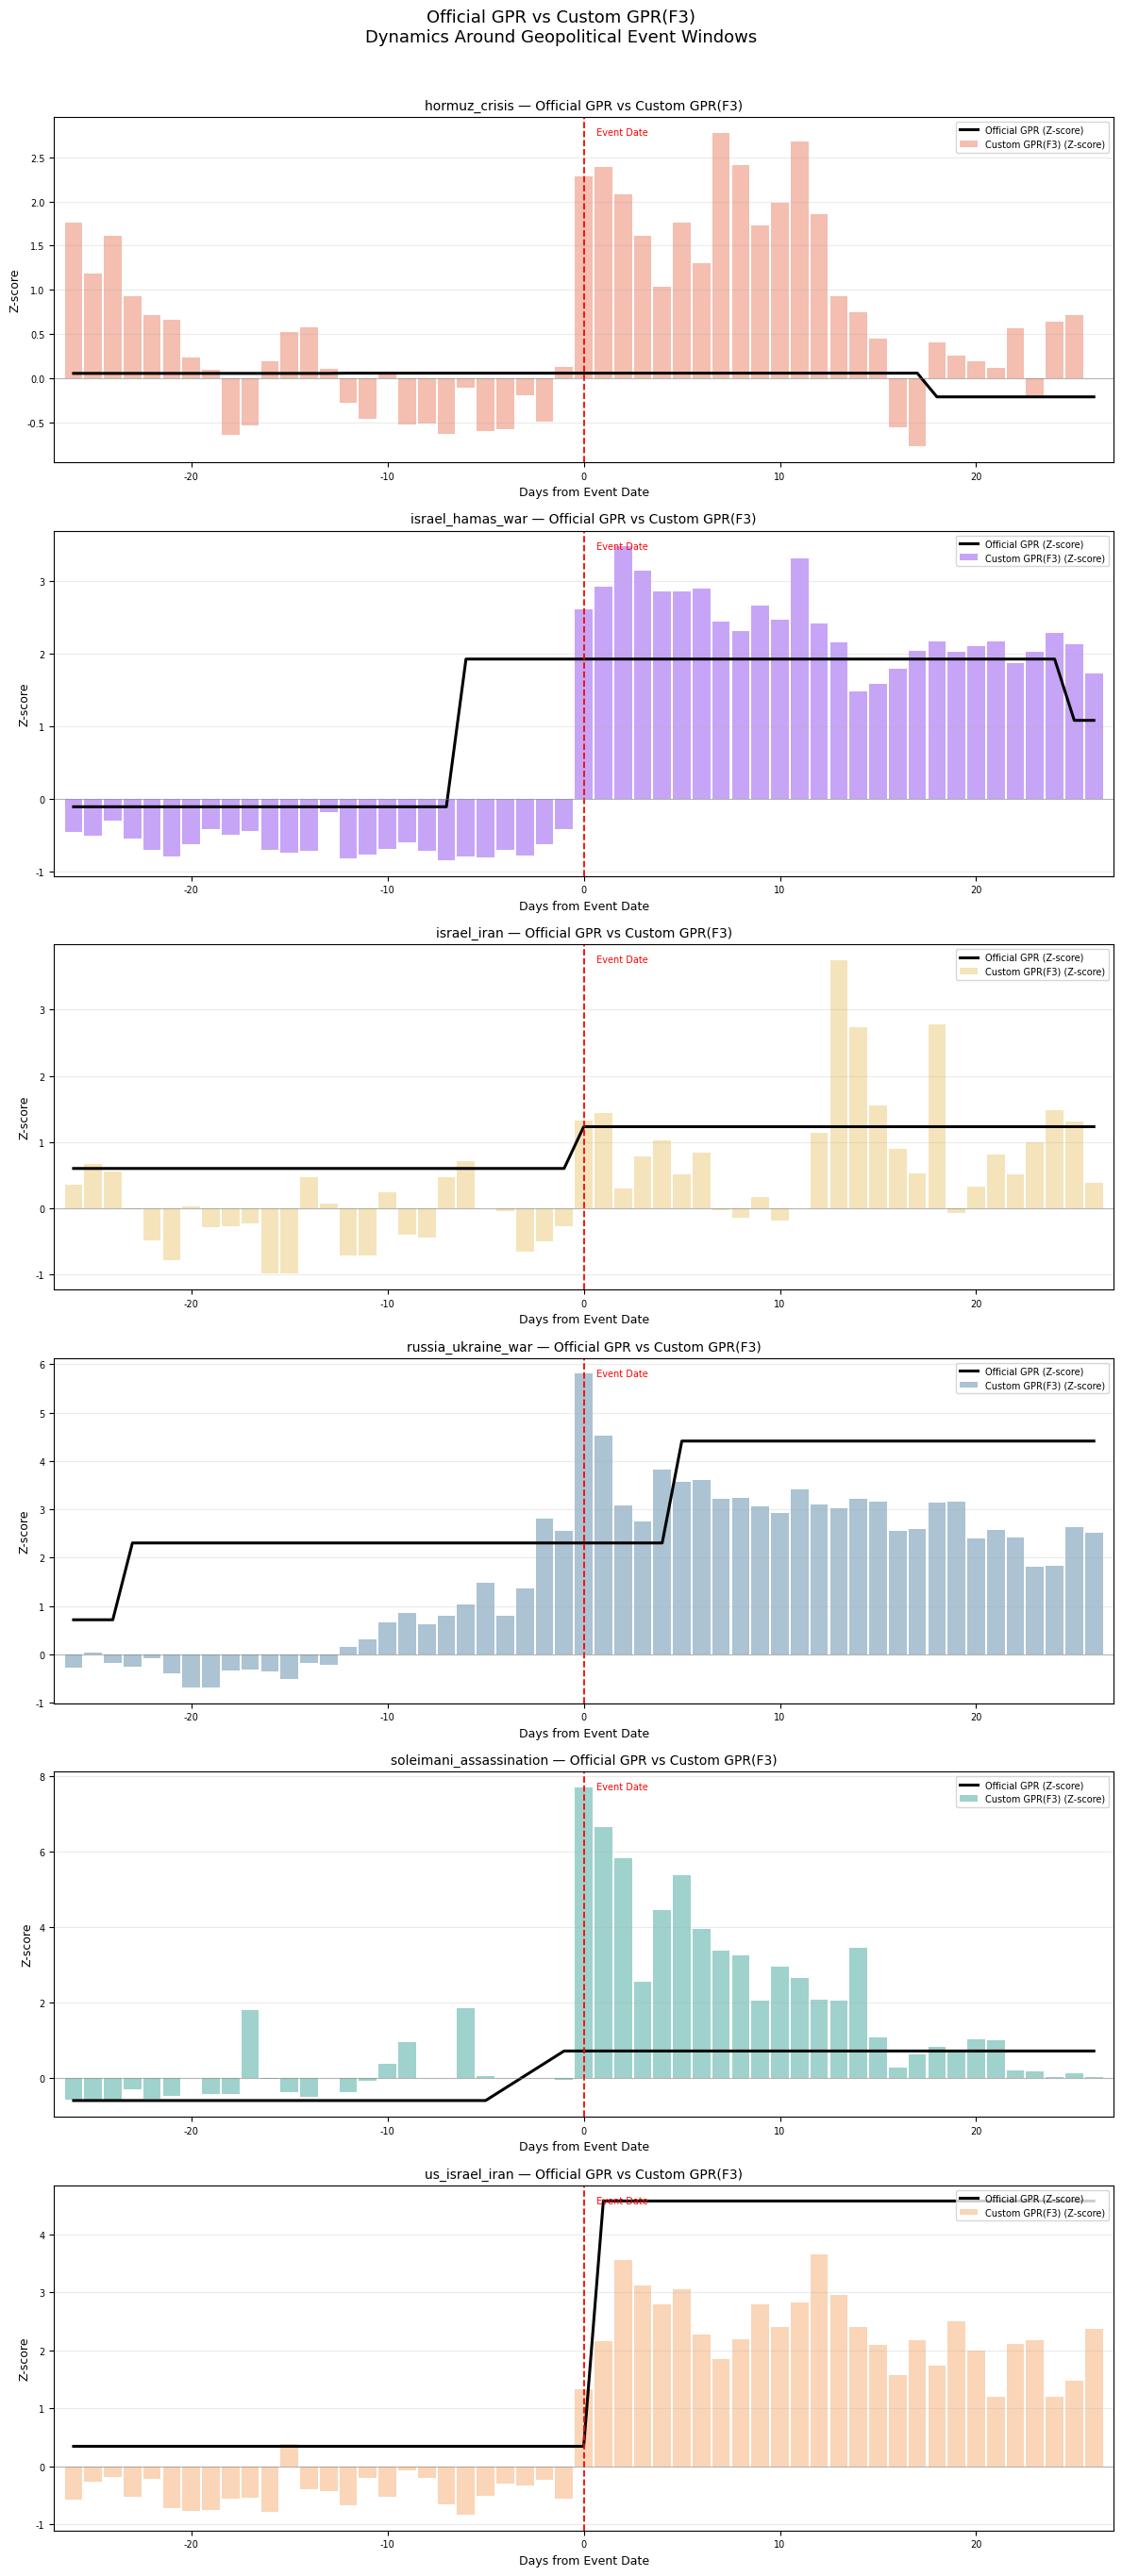

Saved: 07_event_window.png


In [ ]:
WINDOW = 26

n_events = len(merged_results)

fig, axes = plt.subplots(
    n_events,
    1,
    figsize=(12, 4.5 * n_events)
)

if n_events == 1:
    axes = [axes]


for ax, (event, result) in zip(axes, merged_results.items()):

    result = result.copy()

    result['date'] = pd.to_datetime(result['date'])
    result = result.sort_values('date')

    event_dt = pd.Timestamp(EVENT_DATES[event])

    color = COLORS.get(event, 'steelblue')


    result['day_offset'] = (
        result['date'] - event_dt
    ).dt.days

    window_data = result[
        result['day_offset'].between(-WINDOW, WINDOW)
    ].copy()

    ax.bar(
        window_data['day_offset'],
        window_data['F3_z'],
        color=color,
        alpha=0.45,
        width=0.9,
        label='Custom GPR(F3) (Z-score)'
    )

    if 'GPR_zscore' in window_data.columns:

        ax.plot(
            window_data['day_offset'],
            window_data['GPR_zscore'],
            color='black',
            lw=2.2,
            label='Official GPR (Z-score)'
        )

    ax.axvline(
        0,
        color='red',
        lw=1.3,
        ls='--'
    )

    ax.text(
        0.5,
        0.97,
        ' Event Date',
        color='red',
        fontsize=7,
        va='top',
        transform=ax.get_xaxis_transform()
    )
    ax.axhline(
        0,
        color='gray',
        lw=0.8,
        alpha=0.5
    )

    ax.set_xlabel(
        'Days from Event Date',
        fontsize=9
    )

    ax.set_ylabel(
        'Z-score',
        fontsize=9
    )

    ax.set_title(
        (
            f'{EVENT_LABELS.get(event, event)} '
            f'— Official GPR vs Custom GPR(F3)'
        ),
        fontsize=10
    )

    ax.tick_params(
        axis='both',
        labelsize=7
    )

    ax.legend(
        fontsize=7,
        loc='upper right'
    )

    ax.grid(
        axis='y',
        alpha=0.25
    )

    ax.set_xlim(
        -WINDOW - 1,
        WINDOW + 1
    )

plt.suptitle(
    (
        'Official GPR vs Custom GPR(F3)\n'
        'Dynamics Around Geopolitical Event Windows'
    ),
    fontsize=13,
    y=1.01
)

plt.tight_layout()

fig.savefig(
    '07_event_window.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print('Saved: 07_event_window.png')

---
## Step 6. 결과 저장

In [69]:
save_cols = [
    'date','event_name','event_date','N','mean_tone',
    'F1_raw','F2_raw','F3_raw','F4_raw','F5_raw',
    'F1_z','F2_z','F3_z','F4_z','F5_z',
]
if gpr_available:
    save_cols += ['GPR','GPR_zscore']

print('▶ 이벤트별 CSV 저장')
for event, result in merged_results.items():
    out_cols = [c for c in save_cols if c in result.columns]
    fname    = f'gpr_custom_{event}.csv'
    result[out_cols].to_csv(fname, index=False, encoding='utf-8-sig')
    print(f'  ✅ {fname}  ({len(result)}행)')

gpr_all_save = pd.concat(
    [r[[c for c in save_cols if c in r.columns]]
     for r in merged_results.values()],
    ignore_index=True)
gpr_all_save.to_csv('gpr_combined.csv', index=False, encoding='utf-8-sig')
print(f'\n  ✅ gpr_combined.csv  ({len(gpr_all_save)}행)')

if not corr_summary.empty:
    corr_summary.to_csv('gpr_correlation_summary.csv',
                        index=False, encoding='utf-8-sig')
    print('  ✅ gpr_correlation_summary.csv')

print('\n저장 완료')

▶ 이벤트별 CSV 저장
  ✅ gpr_custom_hormuz_crisis.csv  (266행)
  ✅ gpr_custom_israel_hamas_war.csv  (384행)
  ✅ gpr_custom_israel_iran.csv  (438행)
  ✅ gpr_custom_russia_ukraine_war.csv  (686행)
  ✅ gpr_custom_soleimani_assassination.csv  (438행)
  ✅ gpr_custom_us_israel_iran.csv  (393행)

  ✅ gpr_combined.csv  (2605행)
  ✅ gpr_correlation_summary.csv

저장 완료
